# Описание проекта <br>

<div style="text-indent: 20px;">HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.<br>
    
Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. <br>
    
Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли. <br>
    
У вас будет несколько задач. Первая — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. <br>
    
Почему бизнесу это важно: удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.<br>
    
Ваша вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.<br>
Теперь расскажем подробнее о задачах.

# Описание данных

# Задача 1: предсказание уровня удовлетворённости сотрудника <br>
Для этой задачи заказчик предоставил данные с признаками:
* **`'id'`** — уникальный идентификатор сотрудника;
* **`'dept'`** — отдел, в котором работает сотрудник;
* **`'level'`** — уровень занимаемой должности;
* **`'workload'`** — уровень загруженности сотрудника;
* **`'employment_years'`** — длительность работы в компании (в годах);
* **`'last_year_promo'`** — показывает, было ли повышение за последний год;
* **`'last_year_violations'`** — показывает, нарушал ли сотрудник трудовой договор за последний год;
* **`'supervisor_evaluation'`** — оценка качества работы сотрудника, которую дал руководитель;
* **`'salary'`** — ежемесячная зарплата сотрудника;
* **`'job_satisfaction_rate'`** — уровень удовлетворённости сотрудника работой в компании, целевой признак.
    
# Задача 2: предсказание увольнения сотрудника из компании <br>
Для этой задачи вы можете использовать те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: это **`'quit'`** — увольнение сотрудника из компании.
    
# План исследования

* Загрузка и изучение данных
* Предобработка данных
* Исследовательский анализ данных
* Объединение таблиц
* Корреляционный анализ
* Использование пайплайнов
* Анализ важности признаков
* Сегментация покупателей
* Общий вывод

## Загрузка данных

In [1]:
!pip install scikit-learn==1.1.3 -q
!pip install matplotlib==3.5.2 -q
!pip install phik -q
!pip install shap -q

In [2]:
import sklearn
print(sklearn.__version__)

1.1.3


In [3]:
import pandas as pd
import re
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

import phik
import shap

#from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, f_regression

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, \
     StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, recall_score, make_scorer, confusion_matrix

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [4]:
train_job_rate = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
test_features = pd.read_csv('/datasets/test_features.csv')
test_target = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')

In [5]:
train_job_rate.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


In [6]:
train_job_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


Имеются пропуски в датасете тренировочной выборки, по типу данных замечаний нет.

In [7]:
test_features.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [8]:
test_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


Имеются пропуски в датасете входных признаков тестовой выборки, по типу данных замечаний нет.

In [9]:
test_target.head()

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


In [10]:
test_target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


В данном датасете замечаний нет.

### Промежуточный вывод

На данном этапе были загружены данные:
* Тренировочная выборка
* Входные признаки тестовой выборки
* Целевой признак тестовой выборки
В данных имеются пропуски. 

## Предобработка данных

### Проверим датасеты на наличие явных дубликатов

In [11]:
print(train_job_rate.drop(['id'], axis=1).duplicated().sum())
print(train_job_rate.duplicated().sum())

245
0


Явных дубликаты присутствуют, но с разными 'id'. Посмотрим на них.

In [12]:
cols_to_check = [col for col in train_job_rate.columns if col != 'id']
duplicates = train_job_rate[train_job_rate.duplicated(subset=cols_to_check, keep=False)]
duplicates.sort_values(by=cols_to_check).head(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
2856,641547,hr,junior,low,1,no,no,3,13200,0.13
3594,769289,hr,junior,low,1,no,no,3,13200,0.13
424,602303,hr,junior,low,1,no,no,4,13200,0.58
940,920628,hr,junior,low,1,no,no,4,13200,0.58
1757,221861,hr,junior,low,3,no,no,4,13200,0.64
3672,978239,hr,junior,low,3,no,no,4,13200,0.64
1649,785242,hr,junior,low,3,no,no,4,13200,0.67
1809,673632,hr,junior,low,3,no,no,4,13200,0.67
4,693419,hr,junior,medium,1,no,no,3,22800,0.20
3510,142091,hr,junior,medium,1,no,no,3,22800,0.20


По данным видно что  это явные дубли с разными id. Удалим дубликаты

In [13]:
train_job_rate = train_job_rate.drop_duplicates(
    subset=[col for col in train_job_rate.columns if col != 'id']
).reset_index(drop=True)

In [14]:
train_job_rate.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


In [15]:
print(train_job_rate.drop(['id'], axis=1).duplicated().sum())

0


### Проверим наличие неявных дубликатов в данных

In [16]:
def checking_duplicates(a):
    for column in a.select_dtypes(exclude=['number']).columns:
        print(f"Уникальные значения в '{column}': {a[column].unique()}")

In [17]:
checking_duplicates(train_job_rate)

Уникальные значения в 'dept': ['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
Уникальные значения в 'level': ['junior' 'middle' 'sinior' nan]
Уникальные значения в 'workload': ['medium' 'high' 'low']
Уникальные значения в 'last_year_promo': ['no' 'yes']
Уникальные значения в 'last_year_violations': ['no' 'yes']


In [18]:
checking_duplicates(test_features)

Уникальные значения в 'dept': ['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
Уникальные значения в 'level': ['junior' 'middle' 'sinior' nan]
Уникальные значения в 'workload': ['medium' 'low' 'high' ' ']
Уникальные значения в 'last_year_promo': ['no' 'yes']
Уникальные значения в 'last_year_violations': ['no' 'yes']


По неявным дубликатам замечаний нет. Дополнительно потвердились пропуски в данных, а также пробелы. Обработаем их в pipline, для этого заменим наши некоторые пропуски в виде пробелов на значение NaN.

In [19]:
test_features['dept'].replace(' ', np.nan, inplace=True)
test_features['workload'].replace(' ', np.nan, inplace=True)

In [20]:
test_features['dept'].unique()

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan],
      dtype=object)

In [21]:
test_features['workload'].unique()

array(['medium', 'low', 'high', nan], dtype=object)

### Проверим наши числовые значения в датасетах.

In [22]:
train_job_rate.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,3755.000000,3755.000000,3755.000000,3755.000000,3755.000000
mean,543971.018642,3.817044,3.463648,34457.416778,0.532554
std,257519.882511,2.557142,1.026265,15050.643870,0.226393
min,100954.000000,1.000000,1.000000,12000.000000,0.030000
25%,322889.500000,2.000000,3.000000,22800.000000,0.350000
50%,532729.000000,3.000000,4.000000,31200.000000,0.550000
75%,770477.500000,6.000000,4.000000,44400.000000,0.710000
max,999521.000000,10.000000,5.000000,98400.000000,1.000000


In [23]:
test_features.describe()

,id,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,552765.213500,3.666500,3.526500,34066.800000
std,253851.326129,2.537222,0.996892,15398.436729
min,100298.000000,1.000000,1.000000,12000.000000
25%,339052.000000,1.000000,3.000000,22800.000000
50%,550793.000000,3.000000,4.000000,30000.000000
75%,765763.750000,6.000000,4.000000,43200.000000
max,999029.000000,10.000000,5.000000,96000.000000


In [24]:
test_target.describe()

,id,job_satisfaction_rate
count,2000.000000,2000.00000
mean,552765.213500,0.54878
std,253851.326129,0.22011
min,100298.000000,0.03000
25%,339052.000000,0.38000
50%,550793.000000,0.58000
75%,765763.750000,0.72000
max,999029.000000,1.00000


### Промежуточный вывод

На данном этапе мы проверили:
* проверили на наличие дубликатов:
    * явные дубликаты без учета 'id' присутствуют (удалили в тренировочной выборке);
    * неявные дубликаты не обнаружены
    * присутствуют пробелы, заменили их на 'NaN', для последующей обработки в pipeline
* проверили на содержание артефактов числовые значения во всех датафреймах - отсутствуют.

## Исследовательский анализ данных

* Проведем исследовательский анализ данных из каждой таблицы. 

### Посмотрим на распределения признаков. 

Для этого напишем функции, которые будут строить графики распределения.
Первая функция будет строить графики ('Гистрограмма' и 'Ящик с усами') для числовых непрерывных значений.

In [25]:
def plotting_graphs_hist(a, b, c, d, e, xlim=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    fig.suptitle(b, fontsize=14, y=1.02)
    
    a.plot(kind='hist', bins=e, color='#AC1080', grid=True, ax=ax1)
    ax1.set_title(" (Гистограмма)", size=12)
    ax1.set_xlabel(c, size=12)
    ax1.set_ylabel(d, size=12)
    if xlim:
        ax1.set_xlim(xlim[0], xlim[1])
    
    a.name = None
    a.plot(kind='box', vert=False, patch_artist=True, 
           boxprops=dict(facecolor='#1E90FF'), ax=ax2)
    ax2.set_title(" (Ящик с усами)", size=12)
    ax2.set_xlabel(c, size=12)
    ax2.set_ylabel('') 
    ax2.set_yticklabels([])
    
#    fig.text(0.5, -0.05, c, ha='center', va='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    print(a.describe())

Следующие функции напишем для дискретных или категорийных значений.

In [26]:
def plotting_graphs_bar_num(a, b, c, d):
    (a.value_counts().sort_index()
    .plot(kind='bar', grid=True, width=0.8, figsize=(14,6))
    )
    
    plt.xticks(rotation=0)
    plt.title(b, size=15)
    plt.xlabel(c, size=14)
    plt.ylabel(d, size=14)
    plt.show()
    plotting_graphs_box(a, b, c)

In [27]:
def plotting_graphs_box(a, b, c):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), 
                                  gridspec_kw={'width_ratios': [1, 1]}) 
    
    a.name = ''
    a.plot(kind='box', vert=False, patch_artist=True, 
           boxprops=dict(facecolor='#1E90FF'), ax=ax1)
    ax1.set_title(b, size=12)
    ax1.set_xlabel(c, size=12)
    ax1.set_ylabel('') 
    
    ax2.axis('off')
    describe_data = a.describe().to_string(float_format="%.2f")
    ax2.text(0.35, 0.5, describe_data, fontfamily='monospace', va='center', ha='left', fontsize=15)
    ax2.set_title("Описательная статистика", size=12)
    
    plt.tight_layout()
    plt.show()

In [28]:
def plotting_graphs_bar_cat(a, b, c, d):
    (a.value_counts().sort_index()
    .plot(kind='bar', grid=True, width=0.8, figsize=(14,6))
    )
    
    plt.xticks(rotation=0)
    plt.title(b, size=15)
    plt.xlabel(c, size=14)
    plt.ylabel(d, size=14)
    plt.show()

Пятая функция у нас будет строить диаграммы для бинарных признаков.

In [29]:
def plotting_graphs_pie(a, b):
    counts = a.value_counts(normalize=True)
    n = len(counts)
    
    (counts.plot(kind='pie', autopct='%.1f%%', startangle=45,
               colors=['#4CAF50', '#FF5722', '#2196F3'][:n],
               shadow=True, 
               explode=tuple([0.05] + [0]*(n-1)),
               figsize=(6, 6),
               textprops={'fontsize': 14})
    )
    plt.title(b, size=12)
    plt.ylabel('')
    plt.show()

In [30]:
def plotting_graphs_hue(a, b, c, d, e, f):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    sns.barplot(data=a, x=b, y=c,
           hue='job_satisfaction_rate', ax=axes[1])
    axes[1].set_title(d)
    axes[1].set_xlabel(e)
    axes[1].set_ylabel(f)
    sns.histplot(df_market_file, bins=3, kde=True, ax=axes[0],
            hue='job_satisfaction_rate', x=b)
    axes[0].set_title('Маркетинговая и покупательская активности')
    plt.legend(loc='upper left', bbox_to_anchor=(1.0, 0.5), borderaxespad=2, fontsize=14)
    plt.show()

In [31]:
def plotting_graphs_target(a, b, c):
    plt.figure(figsize=(14, 6))
    sns.histplot(a, bins=5, kde=True,
            hue=b, x='job_satisfaction_rate')
    plt.title(c)
    plt.show()

### Приступим к построению графиков распределения. 

#### Начнем по порядку с датасета **`'train_job_rate'`**:
* **`'dept'`**

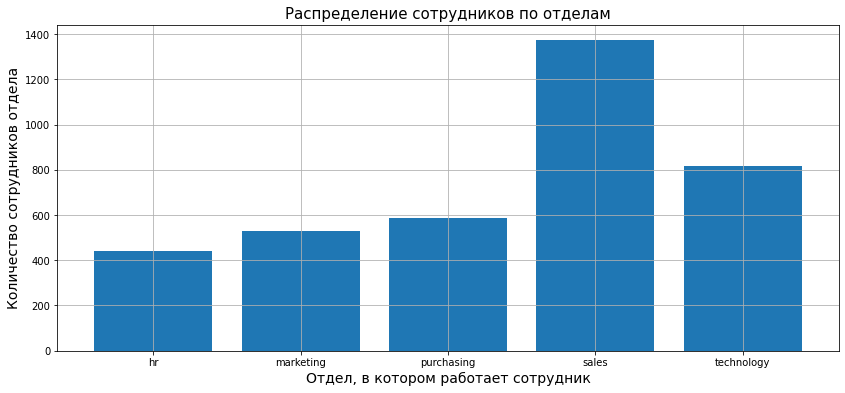

In [32]:
b = 'Распределение сотрудников по отделам'
c = 'Отдел, в котором работает сотрудник'
d = 'Количество сотрудников отдела'
plotting_graphs_bar_cat(train_job_rate['dept'], b, c, d)

* самое большое количество сотрудников в отделе продаж, на втором месте технологический отдел и замыкает тройку лидеров отдел покупок

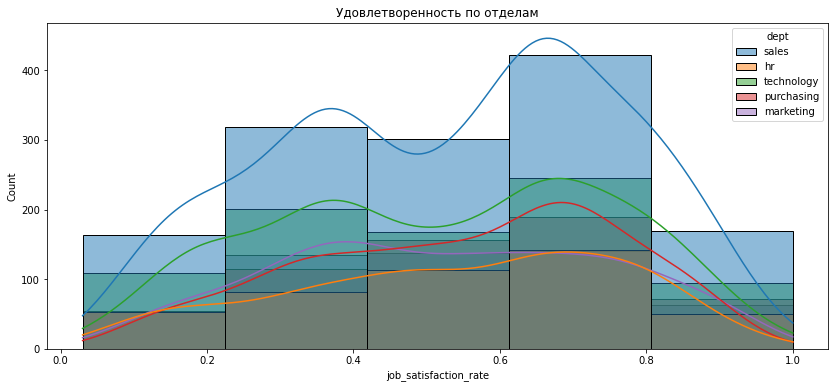

In [33]:
plt.figure(figsize=(14, 6))
sns.histplot(train_job_rate, bins=5, kde=True,
            hue='dept', x='job_satisfaction_rate')
plt.title('Удовлетворенность по отделам')
plt.show()

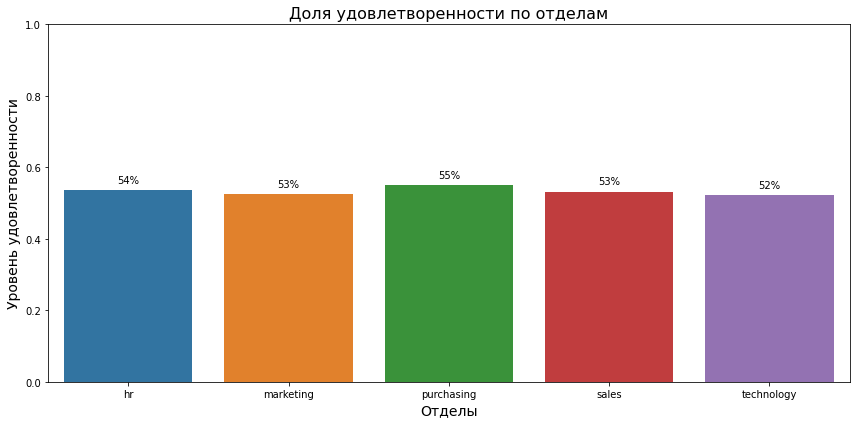

In [34]:
plt.figure(figsize=(12, 6))

df_dept = train_job_rate.groupby('dept')['job_satisfaction_rate'].mean().reset_index()
df_dept = df_dept.rename(columns={
    0: 'job_satisfaction_rate'
})

ax1 = sns.barplot(data=df_dept, x='dept', y='job_satisfaction_rate')
plt.title('Доля удовлетворенности по отделам', size=16)
plt.ylabel('Уровень удовлетворенности', size=14)
plt.xlabel('Отделы', size=14)
plt.ylim(0, 1)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.0%}", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

* При сравнении по долям, видно что доля удовлетворенности выше в отделах покупок и hr, в отличии от отделов маркетинга.ю продаж и технологического.

* **`'level'`**

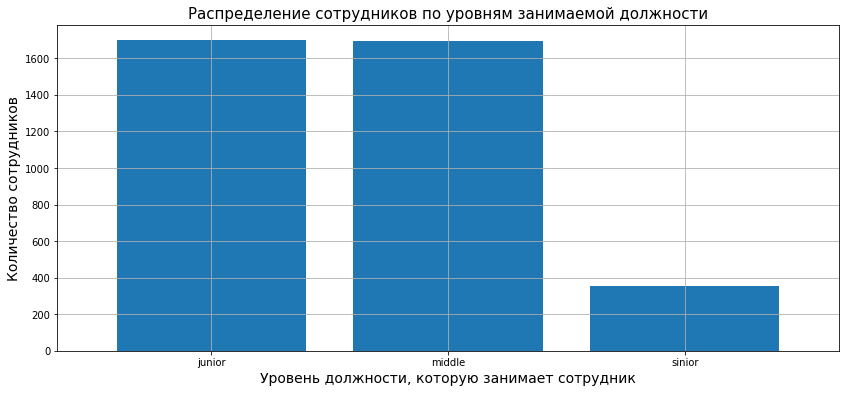

In [35]:
b = 'Распределение сотрудников по уровням занимаемой должности'
c = 'Уровень должности, которую занимает сотрудник'
d = 'Количество сотрудников'
plotting_graphs_bar_cat(train_job_rate['level'], b, c, d)

* количество сотрудников уровня 'junior' и 'middle' значительно превышает специалистов уровня 'sinior'

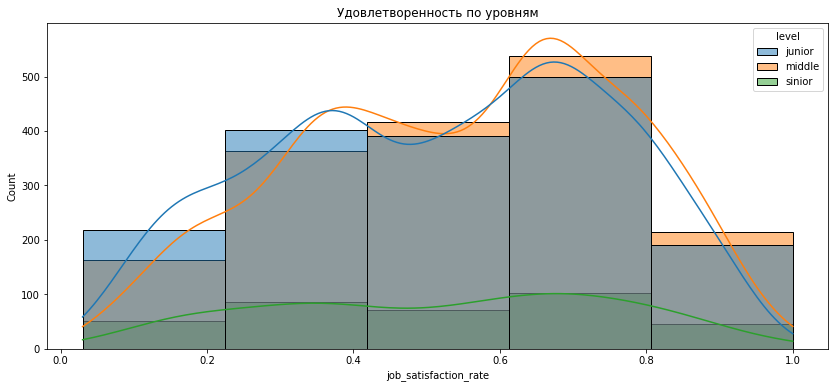

In [36]:
plt.figure(figsize=(14, 6))
sns.histplot(train_job_rate, bins=5, kde=True,
            hue='level', x='job_satisfaction_rate')
plt.title('Удовлетворенность по уровням')
plt.show()

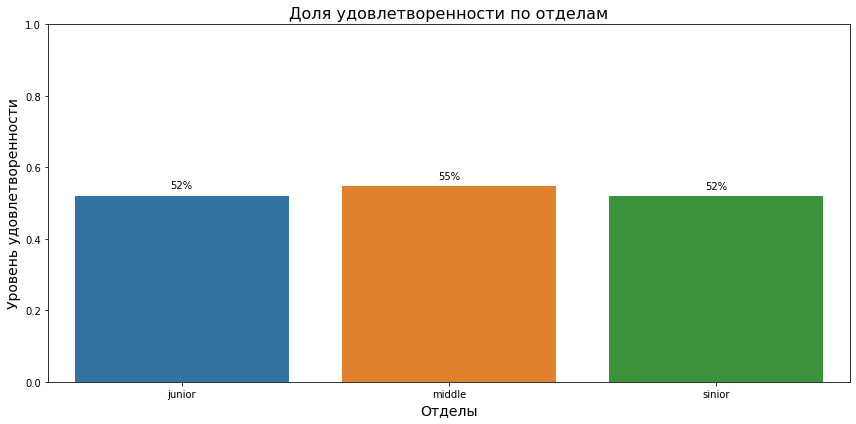

In [37]:
plt.figure(figsize=(12, 6))

df_level = train_job_rate.groupby('level')['job_satisfaction_rate'].mean().reset_index()
df_level = df_level.rename(columns={
    0: 'job_satisfaction_rate'
})

ax1 = sns.barplot(data=df_level, x='level', y='job_satisfaction_rate')
plt.title('Доля удовлетворенности по отделам', size=16)
plt.ylabel('Уровень удовлетворенности', size=14)
plt.xlabel('Отделы', size=14)
plt.ylim(0, 1)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.0%}", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

* При сравнении по долям, видно что доля удовлетворенности выше у специалистов уровня 'middle'

* **`'workload'`**

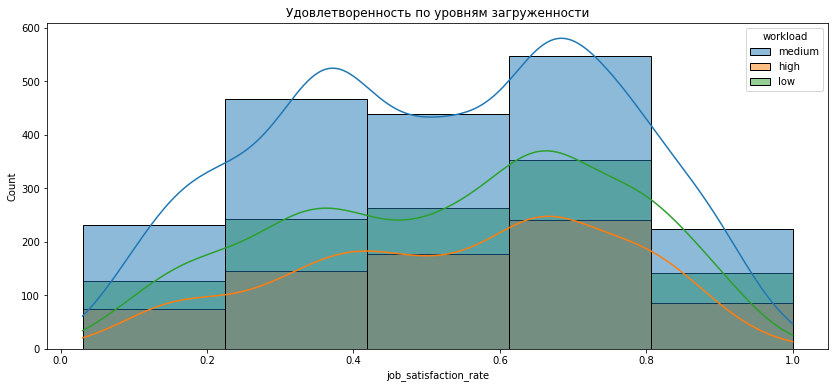

In [38]:
plt.figure(figsize=(14, 6))
sns.histplot(train_job_rate, bins=5, kde=True,
            hue='workload', x='job_satisfaction_rate')
plt.title('Удовлетворенность по уровням загруженности')
plt.show()

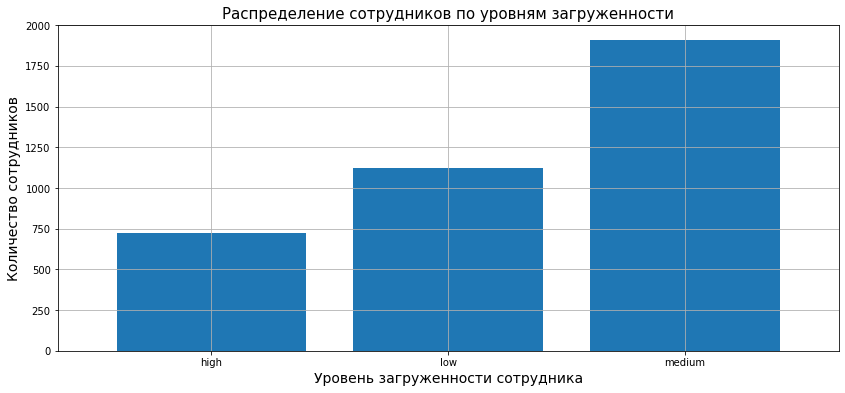

In [39]:
b = 'Распределение сотрудников по уровням загруженности'
c = 'Уровень загруженности сотрудника'
d = 'Количество сотрудников'
plotting_graphs_bar_cat(train_job_rate['workload'], b, c, d)

* по уровню загруженности наибольшая по численности группа - 'medium'
* наибольшое количество сотрудников с большей долей удовлетворенности составлют сотрудники с нагрузками 'medium' и 'low'

* **`'employment_years'`**

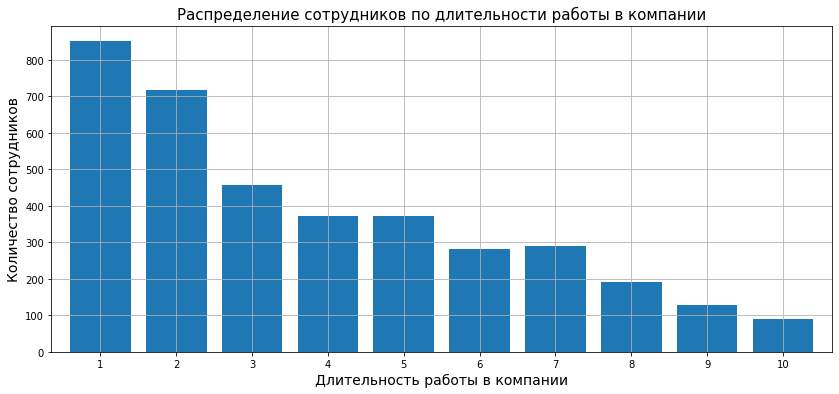

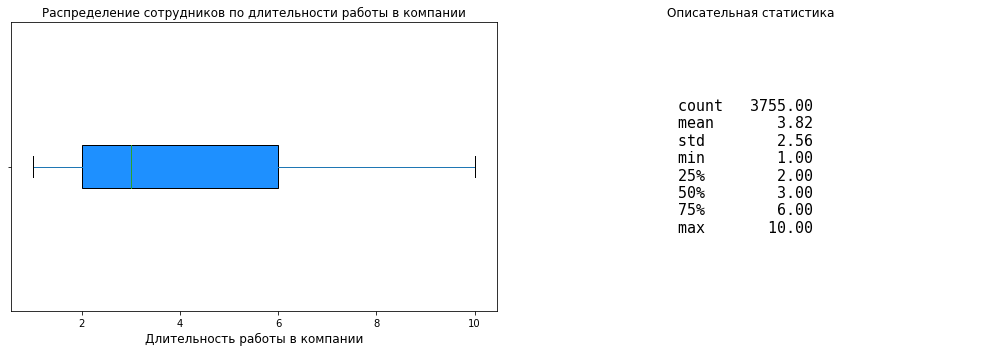

In [40]:
b = 'Распределение сотрудников по длительности работы в компании'
c = 'Длительность работы в компании'
d = 'Количество сотрудников'
plotting_graphs_bar_num(train_job_rate['employment_years'], b, c, d)

* по длительности работы в компании самые многочисленные группы: от 1 до 3х лет, самая малочисленная 10 лет.

* **`'last_year_promo'`**

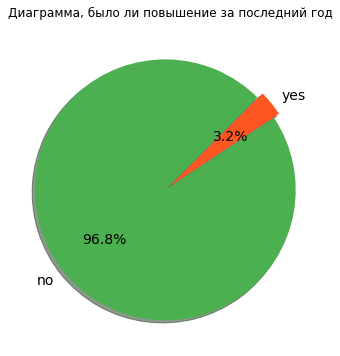

In [41]:
b = 'Диаграмма, было ли повышение за последний год'
plotting_graphs_pie(train_job_rate['last_year_promo'], b)

* у 97% сотрудников не было повышения за последний год.

* **`'last_year_violations'`**

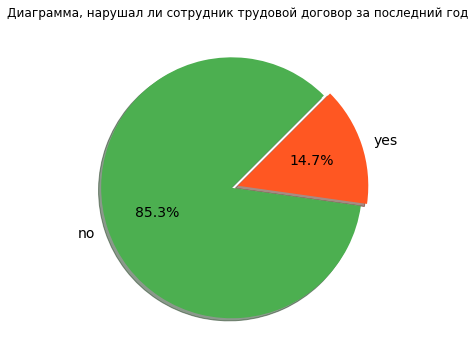

In [42]:
b = 'Диаграмма, нарушал ли сотрудник трудовой договор за последний год'
plotting_graphs_pie(train_job_rate['last_year_violations'], b)

* 15% сотрудников нарушали трудовой договор

* **`'supervisor_evaluation'`**

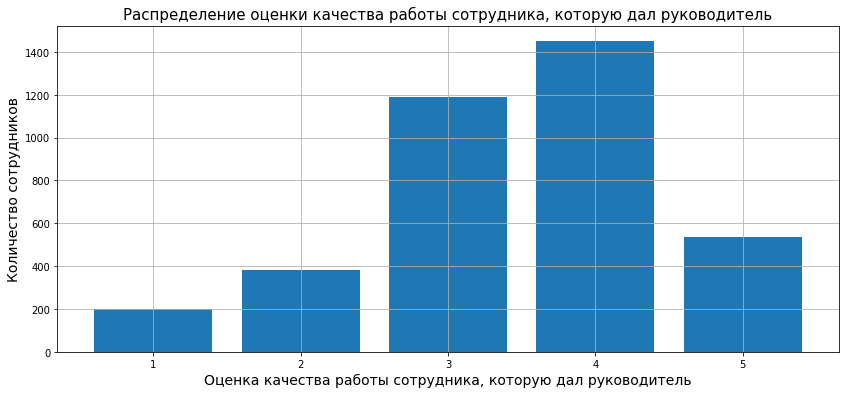

In [43]:
b = 'Распределение оценки качества работы сотрудника, которую дал руководитель'
c = 'Оценка качества работы сотрудника, которую дал руководитель'
d = 'Количество сотрудников'
plotting_graphs_bar_cat(train_job_rate['supervisor_evaluation'], b, c, d)

* по пятибальной шкале, наиболее часто присваемая оценка руководителем сотрудника - 4

* **`'salary'`**

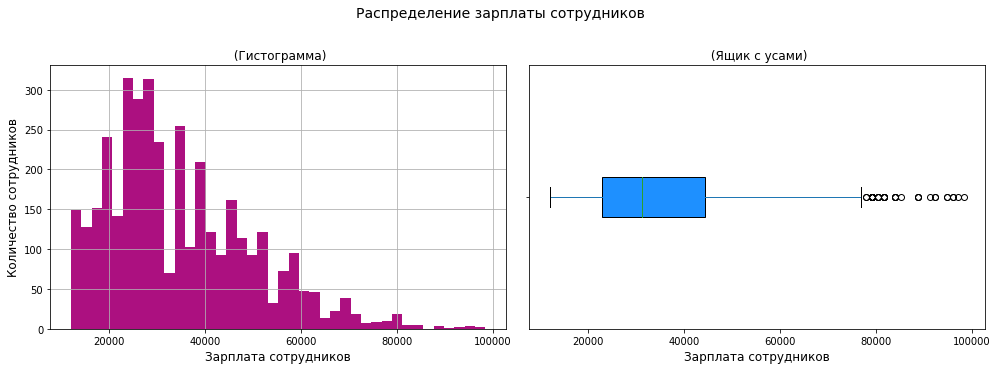

count     3755.000000
mean     34457.416778
std      15050.643870
min      12000.000000
25%      22800.000000
50%      31200.000000
75%      44400.000000
max      98400.000000
dtype: float64


In [44]:
b = 'Распределение зарплаты сотрудников'
c = 'Зарплата сотрудников'
d = 'Количество сотрудников'
e = 40
plotting_graphs_hist(train_job_rate['salary'], b, c, d, e, xlim=None)

* распределение заработка сотрудников далеко от нормального, в данных присутствую выбросы, которые проявляются благодаря немногочисленной группы специалистов уровня сеньор с высокими заработками. Медианное значение составляет 31200, среднее значение выше и составляет 34457.

* **`'job_satisfaction_rate'`**

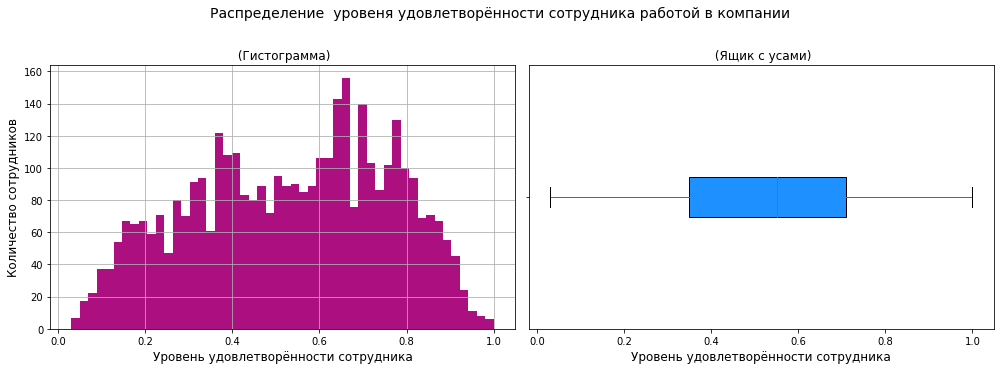

count    3755.000000
mean        0.532554
std         0.226393
min         0.030000
25%         0.350000
50%         0.550000
75%         0.710000
max         1.000000
dtype: float64


In [45]:
b = 'Распределение  уровеня удовлетворённости сотрудника работой в компании'
c = 'Уровень удовлетворённости сотрудника'
d = 'Количество сотрудников'
e = 50
plotting_graphs_hist(train_job_rate['job_satisfaction_rate'], b, c, d, e, xlim=None)

* медианное значение распределения удовлетворенности работой в компании составляет 0.55. Визуально можно наблюдать примерно 2 вершины вокруг которых сосредоточено основное количество.

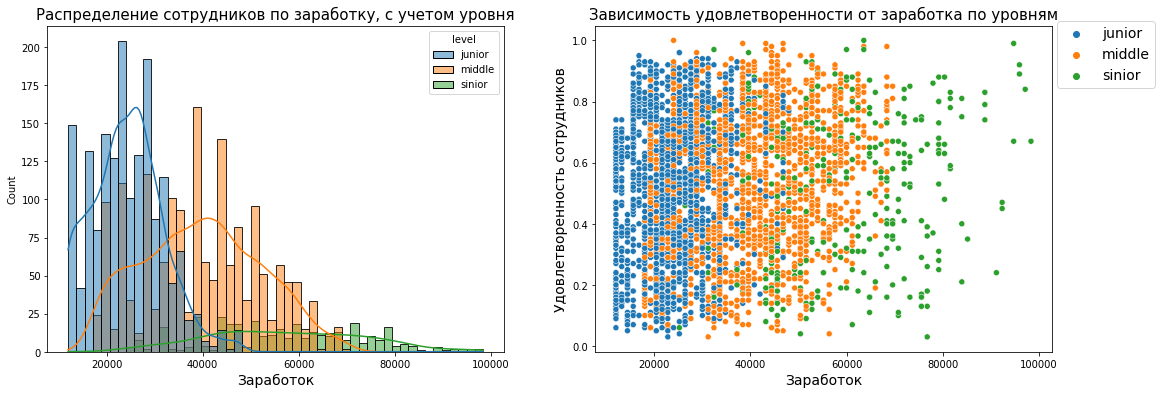

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(train_job_rate, bins=50, kde=True, ax=axes[0],
            hue='level', x='salary')
axes[0].set_title('Распределение сотрудников по заработку, с учетом уровня', size=15)
axes[0].set_xlabel('Заработок', size=14)
sns.scatterplot(data=train_job_rate, x='salary', y='job_satisfaction_rate',
           hue='level', ax=axes[1])
axes[1].set_title('Зависимость удовлетворенности от заработка по уровням', size=15)
axes[1].set_xlabel('Заработок', size=14)
axes[1].set_ylabel('Удовлетворенность сотрудников', size=14)
plt.legend(bbox_to_anchor=(0.95, 1.1), borderaxespad=2, fontsize=14)
plt.show()

* по графикам видно что заработок у сеньоров самая высокая, а самая низкая у джуниоров. По зависимости уровня удовлетворенности от заработка можно наблюдать как изменяется плотность при росте заработка у каждой группы. С ростом заработка плотность увеличивается к более высоким значениям степени удовлетворения сотрудника, возрастает зависимость.

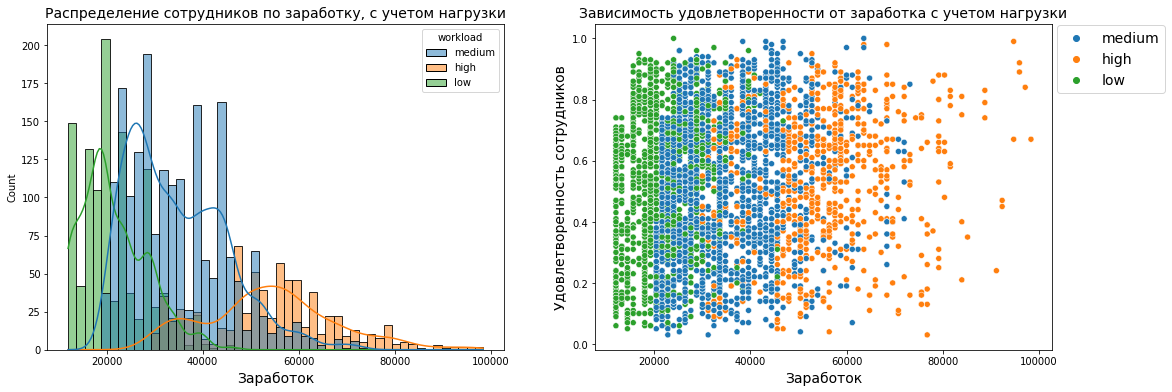

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(train_job_rate, bins=50, kde=True, ax=axes[0],
            hue='workload', x='salary')
axes[0].set_title('Распределение сотрудников по заработку, с учетом нагрузки', size=14)
axes[0].set_xlabel('Заработок', size=14)
sns.scatterplot(data=train_job_rate, x='salary', y='job_satisfaction_rate',
           hue='workload', ax=axes[1])
axes[1].set_title('Зависимость удовлетворенности от заработка с учетом нагрузки', size=14)
axes[1].set_xlabel('Заработок', size=14)
axes[1].set_ylabel('Удовлетворенность сотрудников', size=14)
plt.legend(bbox_to_anchor=(0.95, 1.08), borderaxespad=2, fontsize=14)
plt.show()

* По первому графику все очевидно, чем выше нагрузка -тем выше заработок.
* По второму графику зависимость от заработка удовлетворенности сотрудника с учетом нагрузки более четко прослеживается у группы с низкой и высокой уровнями нагрузки.

In [48]:
pivot_salary_dept = train_job_rate.pivot_table(index='dept', values='salary', aggfunc='mean')
pivot_salary_dept

,salary
dept,
hr,33433.636364
marketing,34745.762712
purchasing,33407.508532
sales,32396.506550
technology,39124.694377


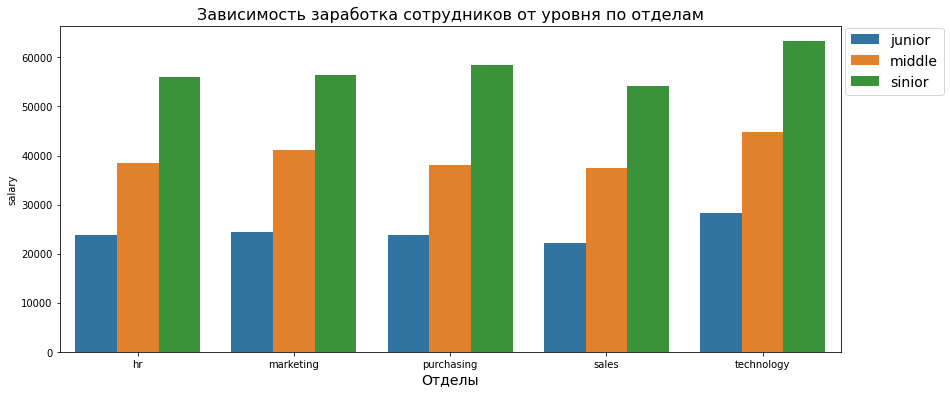

In [49]:
pivot_salary_dept = train_job_rate.pivot_table(index=['dept', 'level'], values='salary', aggfunc='mean').reset_index()
plt.figure(figsize=(14, 6))
sns.barplot(data=pivot_salary_dept,
            hue='level', x='dept', y='salary')
plt.title('Зависимость заработка сотрудников от уровня по отделам', size=16)
plt.xlabel('Отделы', size=14)
plt.legend(bbox_to_anchor=(0.97, 1.08), borderaxespad=2, fontsize=14)
plt.show()

* зависимость заработка от уровня сотрудника по отделам, в лидерах - технологический отдел по всем уровням. остальные отделы сильно не отличаются.

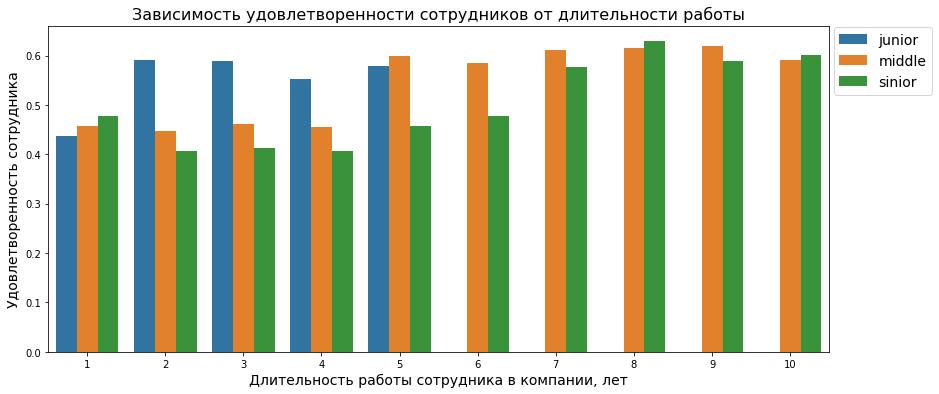

In [50]:
pivot_years_dept = train_job_rate.pivot_table(index=['employment_years', 'level'], values='job_satisfaction_rate', aggfunc='mean').reset_index()
plt.figure(figsize=(14, 6))
sns.barplot(data=pivot_years_dept,
            hue='level', x='employment_years', y='job_satisfaction_rate')
plt.title('Зависимость удовлетворенности сотрудников от длительности работы', size=16)
plt.xlabel('Длительность работы сотрудника в компании, лет', size=14)
plt.ylabel('Удовлетворенность сотрудника', size=14)
plt.legend(bbox_to_anchor=(0.97, 1.08), borderaxespad=2, fontsize=14)
plt.show()

* первый год в компании с учетом адаптации тяжело зачастую, этим можно объяснить низкий уровень средней удовлетворенности сотрудников. По джуниорам мы видим рост на второй годи в дальнейшем небольшой спад, по остальным уровням не наблюдается никакго роста удовлетворенности вплоть до 4 лет, после чего начинается стабильный рост. После 5 лет работы в компании остаются только 2 категории мидл и сеньор.

Проведем корреляционный анализ входящих признаков тренировочной выборки

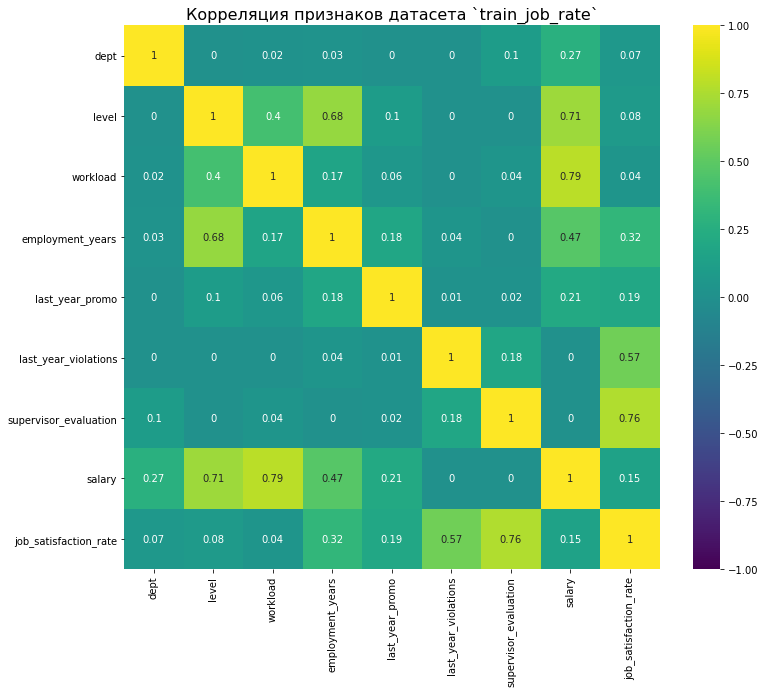

In [51]:
phi_corr = train_job_rate.drop(['id'], 
     axis=1).phik_matrix(interval_cols=[
    'employment_years', 'supervisor_evaluation', 'salary',
    'job_satisfaction_rate']).round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(phi_corr, annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title('Корреляция признаков датасета `train_job_rate`', size=16)
plt.show()

Проведем корреляционный анализ признаков тестовых выборок, для этого объеденим датасеты с входными признаками и целевым таргетом тестовых выборок.

In [52]:
test_df = pd.merge(test_features,test_target, on='id', how='inner')

In [53]:
test_df.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79
1,686555,hr,junior,medium,1,no,no,4,30000,0.72
2,467458,sales,middle,low,5,no,no,4,19200,0.64
3,418655,sales,middle,low,6,no,no,4,19200,0.60
4,789145,hr,middle,medium,5,no,no,5,40800,0.75


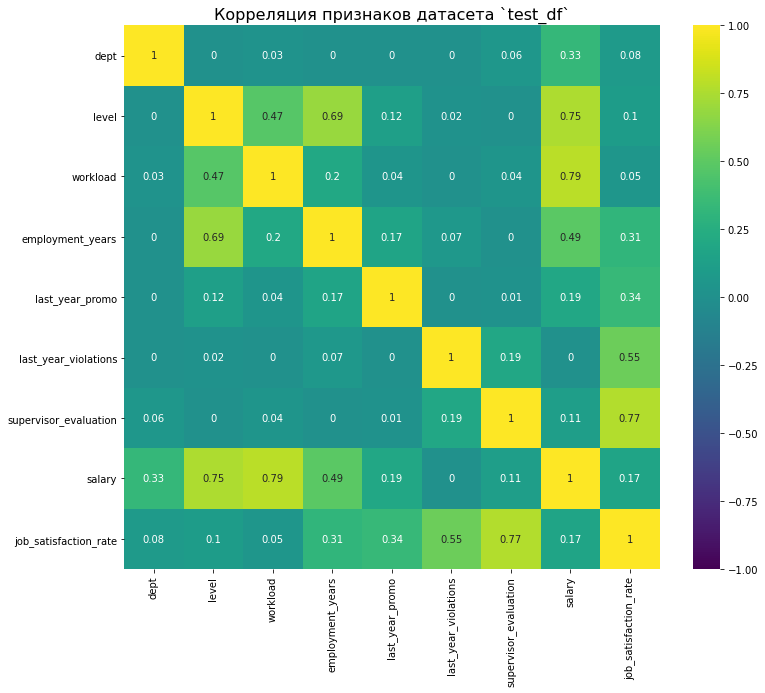

In [54]:
phi_corr = test_df.drop(['id'], 
                        axis=1).phik_matrix(interval_cols=[
    'employment_years', 'supervisor_evaluation', 'salary',
    'job_satisfaction_rate']).round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(phi_corr, annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title('Корреляция признаков датасета `test_df`', size=16)
plt.show()

* по корреляционному анализу видно что:
    * мультиколлинераности между признаками не обнаружено, но имеются значительные корелляции между некоторыми признаками:
        * заработок - загруженность составляет 0.79, что в принципе логично, чем больше загружен специалист и выполняет задачу, тем более выше его эффективность, соответсвенно и она должна оплачиваться соответственно
        * оценка руководителя - удовлетворенность сотрудника 0.76-0.77 (любому сотруднику будет нравиться когда его ценит руководитель)
        * уровень - заработок 0.71, тут тоже все логично, чем выше уровень сотрудника, тем выше его заработок
        * уровень - длительность работы в компании 0.69, аналогично

### Промежуточный вывод

В ходе исследования выявлены некоторые закономерности в данных:

1. Влияние зарплаты:
    По зависимости уровня удовлетворенности от заработка можно наблюдать как изменяется плотность при росте заработка у каждой группы. С ростом заработка плотность увеличивается к более высоким значениям степени удовлетворения сотрудника, возрастает зависимость.
2. При сравнении по долям, видно что доля удовлетворенности выше в отделах покупок и hr, в отличии от отделов маркетинга, продаж и технологического.
3. количество сотрудников уровня 'junior' и 'middle' значительно превышает специалистов уровня 'sinior'
4. При сравнении по долям, видно что доля удовлетворенности выше у специалистов уровня 'middle'
5. По уровню загруженности наибольшая по численности группа - 'medium'. Наибольшое количество сотрудников с большей долей удовлетворенности составлют сотрудники с нагрузками 'medium' и 'low'
6. По длительности работы в компании самые многочисленные группы: от 1 до 3х лет, самая малочисленная 10 лет.
7. у 97% сотрудников не было повышения за последний год. 15% сотрудников нарушали трудовой договор
8. распределение заработка сотрудников далеко от нормального, в данных присутствую выбросы, которые проявляются благодаря немногочисленной группы специалистов уровня сеньор с высокими заработками. Медианное значение составляет 31200, среднее значение выше и составляет 34457.
9. медианное значение распределения удовлетворенности работой в компании составляет 0.55. Визуально можно наблюдать примерно 2 вершины вокруг которых сосредоточено основное количество.
10. по графикам видно что заработок у сеньоров самая высокая, а самая низкая у джуниоров. По зависимости уровня удовлетворенности от заработка можно наблюдать как изменяется плотность при росте заработка у каждой группы. С ростом заработка плотность увеличивается к более высоким значениям степени удовлетворения сотрудника, возрастает зависимость.
11. Чем выше нагрузка -тем выше заработок. Зависимость от заработка удовлетворенности сотрудника с учетом нагрузки более четко прослеживается у группы с низкой и высокой уровнями нагрузки.
12. зависимость заработка от уровня сотрудника по отделам, в лидерах - технологический отдел по всем уровням. остальные отделы сильно не отличаются.
13. первый год в компании с учетом адаптации тяжело зачастую, этим можно объяснить низкий уровень средней удовлетворенности сотрудников. По джуниорам мы видим рост на второй годи в дальнейшем небольшой спад, по остальным уровням не наблюдается никакго роста удовлетворенности вплоть до 4 лет, после чего начинается стабильный рост. После 5 лет работы в компании остаются только 2 категории мидл и сеньор.

## Подготовка данных

In [55]:
RANDOM_STATE = 42

X_train = train_job_rate.drop(['job_satisfaction_rate', 'id'], axis=1)
y_train = train_job_rate['job_satisfaction_rate']
X_test = test_df.drop(['id', 'job_satisfaction_rate'], axis=1)
y_test = test_df['job_satisfaction_rate']

ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level', 'workload']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary']

ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='error', sparse=False))
    ]
    )

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'sinior'],
                    ['low', 'medium', 'high']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', RobustScaler(), num_columns)
    ], 
    remainder='passthrough'
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('selector', SelectKBest(score_func=f_regression)),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

### Промежуточный вывод

При подготовке данных был использован pipeline. Подготовку признаков выполнили в пайплайне, дополнив пайплайн шагом предобработки. При кодировании использовали как два кодировщика, а также подготовили селектор для подбора лучшего сочетания параметров.

##  Обучение моделей

In [56]:
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred))
    smape_value = 100 * np.mean(2 * np.abs(y_pred - y_true) / (denominator + 1e-8))
    return smape_value

smape_score = make_scorer(smape, greater_is_better=False)

In [57]:
param_grid = [
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 17),
        'models__max_features': ['auto', 0.5, 0.7],
        'selector__k': [3, 5, 'all'],
        'selector__score_func': [f_regression],
        'preprocessor__num': [RobustScaler(), StandardScaler(), 'passthrough']  
    },

    {
        'models': [LinearRegression()],
        'selector__k': [3, 5, 'all'],
        'selector__score_func': [f_regression],
        'preprocessor__num': [StandardScaler(), RobustScaler(), 'passthrough']  
    },
]

randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring=smape_score,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_iter=20
)
randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', -randomized_search.best_score_)

y_test_pred = randomized_search.predict(X_test)
print(f'Метрика SMAPE на тестовой выборке: {smape(y_test, y_test_pred)}')

/opt/conda/lib/python3.9/site-packages/sklearn/tree/_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/tree/_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/tree/_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/tree/_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/opt/conda/lib/python3.9/site-pa

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                              

In [58]:
results = pd.DataFrame(randomized_search.cv_results_)
best_results = results.sort_values(by='mean_test_score', ascending=False)
best_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_selector__score_func,param_selector__k,param_preprocessor__num,param_models__max_features,param_models__max_depth,param_models,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,0.104104,0.007688,0.077633,0.033336,<function f_regression at 0x7f8993b41430>,all,passthrough,0.7,14,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-15.605657,-15.318792,-16.527001,-16.619386,-15.886283,-15.991424,0.508623,1
18,0.084156,0.066753,0.117097,0.041208,<function f_regression at 0x7f8993b41430>,all,StandardScaler(),0.5,15,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-16.759490,-16.556851,-17.369350,-16.619408,-17.171867,-16.895393,0.319475,2
7,0.074727,0.032320,0.105831,0.034435,<function f_regression at 0x7f8993b41430>,all,StandardScaler(),auto,7,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-18.288828,-16.870524,-19.076341,-18.826786,-18.662191,-18.344934,0.780362,3
11,0.060561,0.042091,0.120049,0.045390,<function f_regression at 0x7f8993b41430>,all,StandardScaler(),0.7,6,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-19.866974,-18.958545,-20.147330,-20.484096,-19.870789,-19.865547,0.506890,4
10,0.078742,0.043680,0.119308,0.047697,<function f_regression at 0x7f8993b41430>,5,RobustScaler(),0.5,6,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-21.424877,-20.234711,-22.096556,-22.011482,-20.299797,-21.213485,0.806737,5
6,0.080077,0.043212,0.119856,0.043795,<function f_regression at 0x7f8993b41430>,5,RobustScaler(),0.7,11,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-20.999163,-20.832097,-21.698827,-22.508428,-20.737017,-21.355106,0.667917,6
16,0.098179,0.035372,0.083037,0.004680,<function f_regression at 0x7f8993b41430>,all,RobustScaler(),auto,4,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-21.641458,-20.724117,-22.637705,-21.792710,-20.808390,-21.520876,0.704017,7
13,0.062674,0.045781,0.118414,0.045531,<function f_regression at 0x7f8993b41430>,5,RobustScaler(),auto,4,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-21.765664,-20.747210,-22.676755,-21.831474,-21.334370,-21.671095,0.634502,8
3,0.076077,0.042627,0.102224,0.038119,<function f_regression at 0x7f8993b41430>,3,StandardScaler(),0.7,16,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-22.676659,-20.775262,-22.436999,-21.895903,-21.526992,-21.862363,0.676561,9
4,0.096077,0.036095,0.102791,0.037109,<function f_regression at 0x7f8993b41430>,3,RobustScaler(),0.7,15,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-22.676659,-20.775262,-22.436999,-21.895903,-21.526992,-21.862363,0.676561,9


### Оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP

  0%|          | 0/2000 [00:00<?, ?it/s]

Best parameters: {'selector__score_func': <function f_regression at 0x7f8993b41430>, 'selector__k': 'all', 'preprocessor__num': 'passthrough', 'models__max_features': 0.7, 'models__max_depth': 14, 'models': DecisionTreeRegressor(max_depth=14, max_features=0.7, random_state=42)}


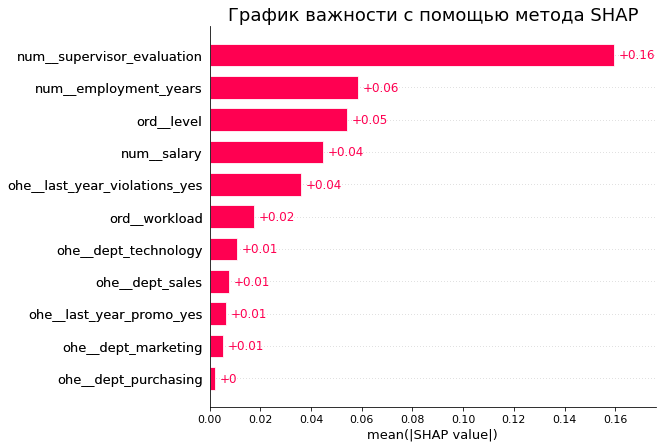

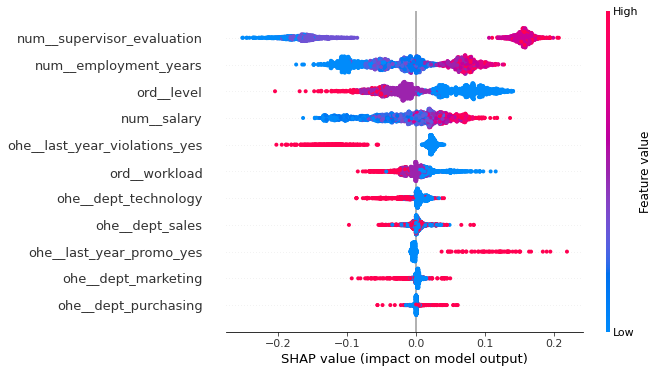

In [59]:
best_pipeline = randomized_search.best_estimator_
selector = best_pipeline.named_steps['selector']
dic_model = best_pipeline.named_steps['models']
    
preprocessor = best_pipeline.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()
X_train_transformed = pd.DataFrame(
    preprocessor.transform(X_train), 
    columns=feature_names
)
X_test_transformed = pd.DataFrame(
    preprocessor.transform(X_test), 
    columns=feature_names
)

X_train_selected = selector.fit_transform(X_train_transformed, y_train)
X_test_selected = selector.transform(X_test_transformed)
selected_feature_names = feature_names[selector.get_support()]

selected_mask = selector.get_support()
selected_feature_names = feature_names[selected_mask]

selector.feature_names_in_ = preprocessor.get_feature_names_out()
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names)

background = shap.sample(X_train_selected, 100)

explainer = shap.KernelExplainer(
        dic_model.predict,
        background,
        feature_names=feature_names,
        n_jobs=-1
    )

shap_values = explainer(X_test_selected_df)

plt.title('График важности с помощью метода SHAP', size=18)
print(f'Best parameters: {randomized_search.best_params_}')
#shap.plots.bar(shap_values[...,1])
shap.plots.bar(shap_values, max_display=17)
shap.plots.beeswarm(shap_values, max_display=17)
plt.show()

### Промежуточный вывод

1. Мы построили пайплайны, для поиска наилучшей модели. которая бы определяла лучше всего степень удовлетворённости сотрудниками рабочего процесса. Для критерия оценки мы создали свою метрику SMAPE через функцию. 
2. В итоге была выбрана модель DecisionTreeRegressor, с парамметрами:max_depth=14, max_features=0.7, random_state=42,  и метрикой на тренировочных данных 15.99.
3. На тестовых данных метрика должна по условию задачи быть ниже 15. По итогу получилось SMAPE = 14.83, что удовлетворяет условия задачи.
4. Мы сохранили все  модели, которые перебирали для решения задачи в отдельный датафрейм.
5. По оценке важности признаков на первом месте с сильным отрывом находится оценка сотрудника руководителем, далее по убыванию - длительность работы в компании, уровень, заработок и нарушение трудового договора. Остальные признаки имеюют минимальное влияние.

## Вывод по задаче 1

Нашей первой целью было — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. 
Удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.

* Для решения задачи была проведена работа, в ходе которой были выявлены, как аномалии, так и закономерности.
    На этапе предобработки данных:
    * проверили на наличие дубликатов:
        * явные дубликаты без учета 'id' присутствуют (удалили в тренировочной выборке);
        * неявные дубликаты не обнаружены
        * присутствуют пробелы, заменили их на 'NaN', для последующей обработки в pipeline
    * проверили на содержание артефактов числовые значения во всех датафреймах - отсутствуют.

* На этапе исследования данных:
    - Выявили зависимость целевого признака от зарплаты сотрудников у группы sinior.
    - Самые низкие средние зарплаты в отделе sales
    - Степень загруженности работников влияет на решение об удовлетворённости рабочим процессом, если она(нагрузка) слабая - риска нет, в то время как при средней и высокой нагрузке - риск снижения удовлетворённостью работы увеличивается.
    - Низкие оценки от руководства сильно расстраивают сотрудников.

* На этапе подготовки данных:
    - Были объеденены датасеты тестовых выборок по 'id', для дальнейшего их использования в pipeline.
    - Мы избавились от пропусков в данных методом заполнения пропусков самым частотным значением.
    - Мы закодировали часть признаков двумя методами и масштабировали признаки,где была такая необходимость.


* На этапе обучения модели:
    - Мы ввели кастомную метрику в соответствиями с условиями задачи.
    - С помошью random search выбрали наилучшую модель, предсказывающую степень удовлетворенности сотрудников рабочим процессом. **Лучшей оказалась модель: DecisionTreeRegressor, с парамметрами:max_depth=14, max_features=0.7, random_state=42, и метрикой на тестовых данных 14.83.**

* Итоги по проделанной работе.
    - В итоге мы нашли модель которая наилучшим образом предсказывает целевой признак - DecisionTreeRegressor.<br>

**По интерпретации модели, и того, как она оценивает удовлетворённость, а также какие именно признаки сильнее влияют на положительную оценку сотрудников удовлетворенности раб.процессом.**<br>

1. Самым важным фактором модель сочла длительность работы в компании. В целом исследовательский анализ также подствердил связь времени работы сотрудников в компании и степерью их удовлетворенности работой. Как же это влиет, согласно анализу shap:
   - Чем больше лет человек проработал, тем выше будет его оценка раб. процессу. Благодая исследовани признаков мы увидели, что оценку удовлетворенности выше среднего чаще ставят группы работников уровня junior, проработашие более 1 года, middle, проработавшие свыше 5 лет, и sinior, проработавшие более 7 лет. Эти категории наименее рискованные из всех. Остальные в зоне риска.
   
   
2. Вторым по важности признаков модель выывела - оценку работы сотрудника руководителем. Согласно анализу shap, чем выше оценивает руководитель работу сотрудника, тем выше сотрудник оценивает свои условия труда в компании, и такая же обратная связь. 
      

3. На третем месте сразу два признака. Зарплата и было ли нарушение трудового договора за последний год. 
   * Зарплата действительно влияет на степень удовлетворенности сотрудниками работой. Согласно исследованию, были выявлены очень чувствительные сегменты работников, к размеру зарплаты.Самые низкие средние зарплаты в отделе sales, при этом ниже всего оценивают удовлетворенность sinior в данной группе - это высокий риск потери первоклассных специалистов, способных увести базу покупателей за собой, уйдя из компании, а также переманить специалистов своего отдела.
   * Согласно исследованию и интерпретации значения признаков методом shap, наличие нарушений трудового договора - это сигнал о том, что сотрудник не доволен тем как организован его рабочий процесс, тут нужно разбираться детальнее, о каких нарушениях речь, возможно снизить риск снижения удовлетворённости данных сотрудников поможет снизить пересмотр условий труда, а не наказание за нарушение договора. 

# Задача 2: предсказание увольнения сотрудника из компании

## Загрузка данных

In [60]:
train_quit = pd.read_csv('/datasets/train_quit.csv')
test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')

In [61]:
train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


In [62]:
train_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


In [63]:
test_target_quit.head()

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


In [64]:
test_target_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


### Промежуточный вывод

На данном этапе были загружены данные:
* Тренировочная выборка
* Входные признаки тестовой выборки
* Целевой признак тестовой выборки
В данных имеются пропуски. 

## Предобработка данных

### Проверим датасеты на наличие явных дубликатов

In [65]:
train_quit.duplicated().sum()

0

In [66]:
test_target_quit.duplicated().sum()

0

Явных дубликатов нет.

In [67]:
checking_duplicates(train_quit)

Уникальные значения в 'dept': ['sales' 'purchasing' 'marketing' 'technology' 'hr']
Уникальные значения в 'level': ['middle' 'junior' 'sinior']
Уникальные значения в 'workload': ['high' 'medium' 'low']
Уникальные значения в 'last_year_promo': ['no' 'yes']
Уникальные значения в 'last_year_violations': ['no' 'yes']
Уникальные значения в 'quit': ['no' 'yes']


In [68]:
checking_duplicates(test_features)

Уникальные значения в 'dept': ['marketing' 'hr' 'sales' 'purchasing' 'technology' nan]
Уникальные значения в 'level': ['junior' 'middle' 'sinior' nan]
Уникальные значения в 'workload': ['medium' 'low' 'high' nan]
Уникальные значения в 'last_year_promo': ['no' 'yes']
Уникальные значения в 'last_year_violations': ['no' 'yes']


Явных дубликатов нет. Наблюдается потверждение наличия пропусков, обработаем их в pipeline.

### Промежуточный вывод


На данном этапе мы проверили:
* проверили на наличие дубликатов:
    * неявные дубликаты не обнаружены
    * присутствуют пропуски, обработаем их в pipeline

## Исследовательский анализ данных

### Составим портрет «уволившегося сотрудника». Например, в каком отделе с большей вероятностью работает уволившийся сотрудник и какой у него уровень загруженности. Также сравним среднее значение зарплаты ушедших сотрудников с теми, кто остался в компании.

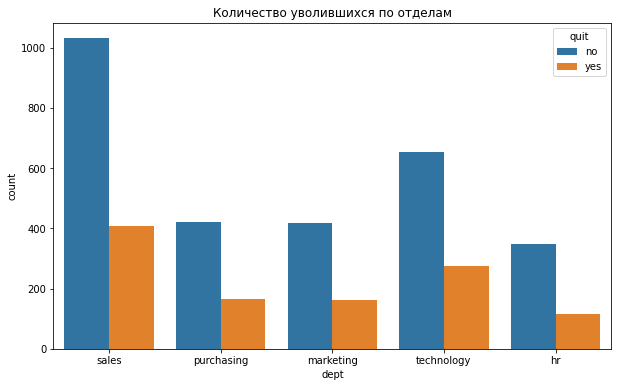

In [69]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_quit, x='dept', hue='quit')
plt.title('Количество уволившихся по отделам')
plt.show()

* По колличеству уволившихся лидируют отделы:
    * продаж и технологический
    * остальные находятся примернно на одном уровне

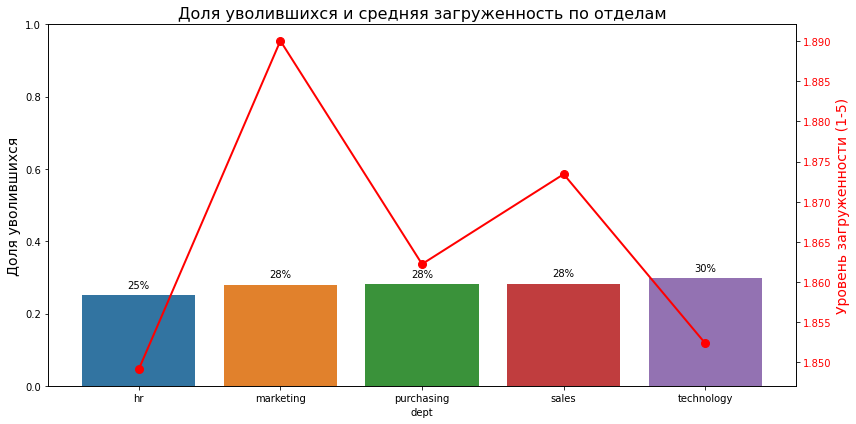

In [70]:
df = train_quit.copy()
df['quit'] = df['quit'].map({'yes': 1, 'no': 0})
workload_map = {'low': 1, 'medium': 2, 'high': 3}
df['workload'] = df['workload'].map(workload_map)
plt.figure(figsize=(12, 6))

dept_left = df.groupby('dept')['quit'].mean().reset_index()

ax1 = sns.barplot(data=dept_left, x='dept', y='quit')
plt.title('Доля уволившихся и средняя загруженность по отделам', size=16)
plt.ylabel('Доля уволившихся', size=14)
plt.ylim(0, 1)

ax2 = ax1.twinx()
workload_by_dept = df.groupby('dept')['workload'].mean()
ax2.plot(ax1.get_xticks(), workload_by_dept, 
         'r-', marker='o', linewidth=2, markersize=8, label='Загруженность')
ax2.set_ylabel('Уровень загруженности (1-5)', color='r', size=14)
ax2.tick_params(axis='y', labelcolor='r')
ax2.grid(False)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.0%}", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

* при рассмотрении доли уволившихся по отделам в разрезе уровня нагруженности:
    * на первом месте 30% уволившихся в технологическом отделе, при этом нагрузка находится практически на минимальном уровне
    * среди остальных можно выделить отдел марктинга и продаж по 28%, имеют нагруженность выше среднего.
    * самая маленькая нагруженность и доля уволившихся в отделе hr

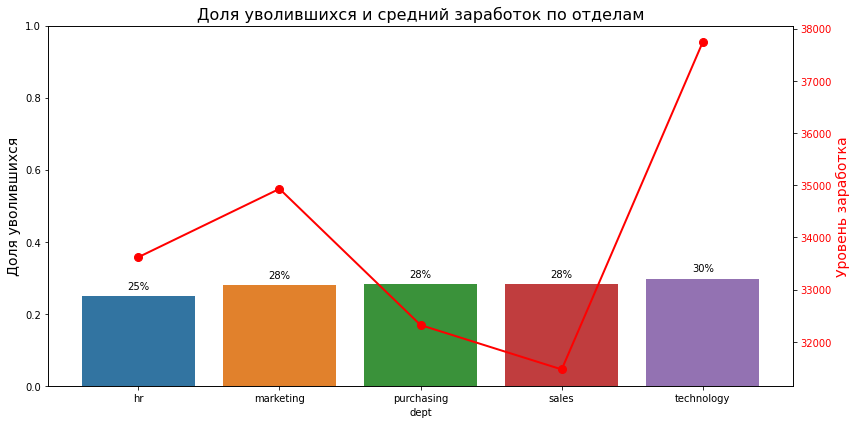

In [71]:
plt.figure(figsize=(12, 6))

dept_left = df.groupby('dept')['quit'].mean().reset_index()

ax1 = sns.barplot(data=dept_left, x='dept', y='quit')
plt.title('Доля уволившихся и средний заработок по отделам', size=16)
plt.ylabel('Доля уволившихся', size=14)
plt.ylim(0, 1)

ax2 = ax1.twinx()
workload_by_dept = df.groupby('dept')['salary'].mean()
ax2.plot(ax1.get_xticks(), workload_by_dept, 
         'r-', marker='o', linewidth=2, markersize=8, label='Заработок')
ax2.set_ylabel('Уровень заработка', color='r', size=14)
ax2.tick_params(axis='y', labelcolor='r')
ax2.grid(False)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.0%}", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

* при рассмотрении доли уволившихся по отделам в разрезе уровня заработка:
    * на первом месте все аткже 30% уволившихся в технологическом отделе, при этом заработок там на максимальном уровне по отношению к другим
    * среди остальных можно выделить отдел марктинга, закупок и продаж по 28%, имеют уровень заработка (маркетинг - средний, закупок и продаж самые низкие).
    * самая маленькая доля уволившихся в отделе hr, с уровнем заработка чуть ниже среднего

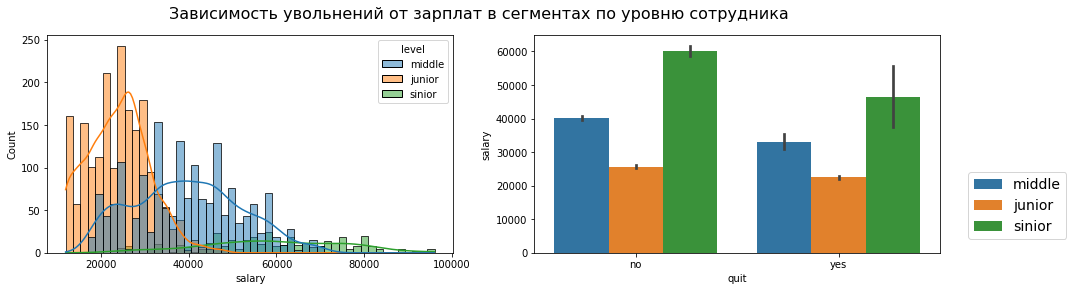

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(data=train_quit, x='quit' , y='salary',
              hue='level')
        
sns.histplot(train_quit, bins=50, kde=True, ax=axes[0], \
             hue='level', x='salary')
plt.suptitle('Зависимость увольнений от зарплат в сегментах по уровню сотрудника', fontsize=16)
plt.legend(loc='upper left',bbox_to_anchor=(1.0, 0.5), borderaxespad= 2, fontsize = 14)
plt.show()


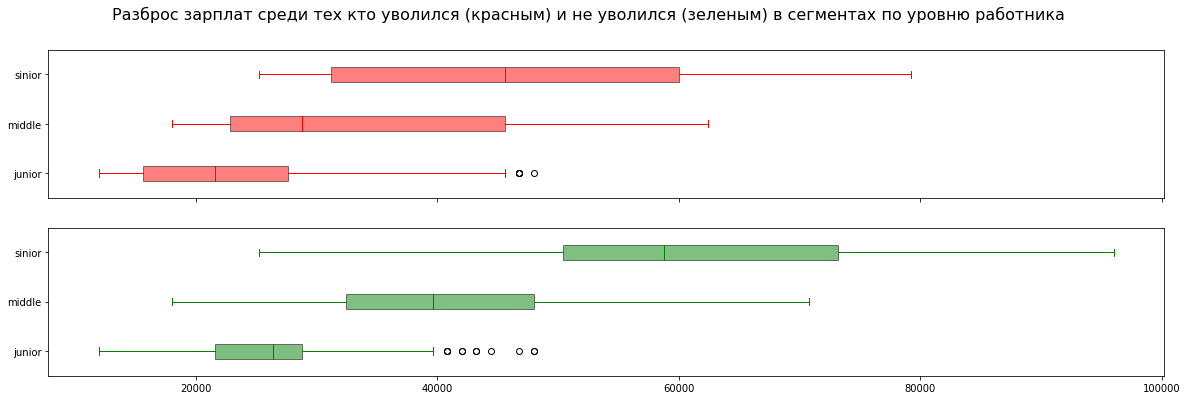

In [73]:
pivot_quit_salary = pd.pivot_table(
    train_quit, 
    index = ['id','quit'], 
    columns = 'level',
    values = 'salary', 
    aggfunc = 'first'
).reset_index()

fig, (ax_box_1, ax_box_2) = plt.subplots(2, sharex=True, figsize=(10,5), gridspec_kw={"height_ratios": (.5, .5)})
plt.suptitle('Разброс зарплат среди тех кто уволился (красным) и не уволился (зеленым) в сегментах по уровню работника',\
          fontsize=16)

pivot_quit_salary.drop('id', axis=1).query('quit=="yes"').plot(
    kind='box', 
    vert=False, 
    figsize=(20, 6), 
    color='red', 
    ax=ax_box_1,
    patch_artist=True, 
    boxprops=dict(facecolor='red', alpha=0.5) 
)

pivot_quit_salary.drop('id', axis=1).query('quit=="no"').plot(
    kind='box', 
    vert=False, 
    figsize=(20, 6), 
    color='green', 
    ax=ax_box_2,
    patch_artist=True,
    boxprops=dict(facecolor='green', alpha=0.5)
)

plt.show() 

Сравнение средних значений зарплат, и их разброса по сегментам уволившихся и тех кто остался, показывает, что увольняются чаще те, кто получает зарплаты ниже среднего.<br>
Рискованные сегменты:<br>
- junior, получающий менее 22000.
- middle, получающий менее 36000. 
- sinior, получающий менее 50000.

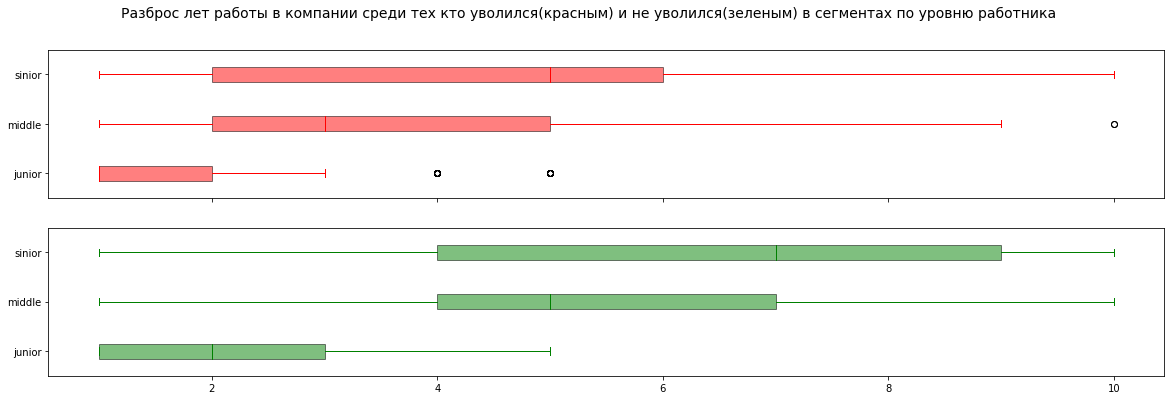

In [74]:
pivot_quit_years = pd.pivot_table(
    train_quit, 
    index = ['id','quit'], 
    columns = 'level',
    values = 'employment_years', 
    aggfunc = 'first'
).reset_index()

fig, (ax_box_1, ax_box_2) = plt.subplots(2, sharex=True, figsize=(10,5), gridspec_kw={"height_ratios": (.5, .5)})
plt.suptitle('Разброс лет работы в компании среди тех кто уволился(красным) и не уволился(зеленым) в сегментах по уровню работника',\
          fontsize=14)

pivot_quit_years.drop('id', axis=1).query('quit=="yes"').plot(
    kind='box', 
    vert=False, 
    figsize=(20, 6), 
    color='red', 
    ax=ax_box_1,
    patch_artist=True, 
    boxprops=dict(facecolor='red', alpha=0.5) 
)

pivot_quit_years.drop('id', axis=1).query('quit=="no"').plot(
    kind='box', 
    vert=False, 
    figsize=(20, 6), 
    color='green', 
    ax=ax_box_2,
    patch_artist=True,
    boxprops=dict(facecolor='green', alpha=0.5)
)

plt.show() 

Как мы видим, из графиков, большинство мидл и синиор сотрудников (оно и понятно что не джуниоров), которые остаются в компании работают свыше 4 лет.<br>
Большинство уволившихся сотрудников в разных сегментах работали в компании меньше 5лет.<br> 
Рискованные сегменты:
- junior, работающий менее 2 лет.
- middle, работающий менее 5 лет. 
- sinior, работающий менее 6 лет.

### Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Проверим это утверждение: визуализируем и сравним распределения признака 'job_satisfaction_rate' для ушедших и оставшихся сотрудников. Используем данные с обоими целевыми признаками тестовой выборки.

In [75]:
df_quit = test_target.merge(test_target_quit, on='id', how='inner')

In [76]:
df_quit.head()

,id,job_satisfaction_rate,quit
0,130604,0.74,no
1,825977,0.75,no
2,418490,0.60,yes
3,555320,0.72,no
4,826430,0.08,yes


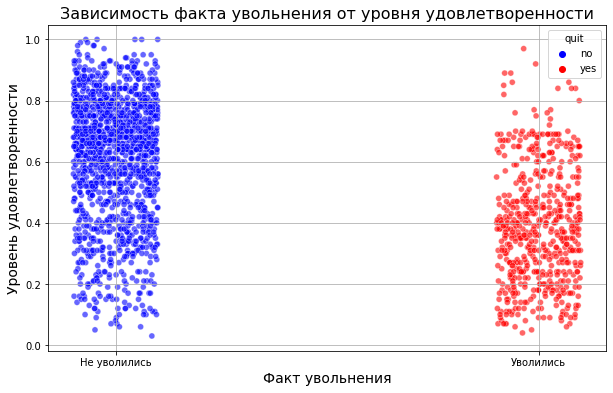

In [77]:
plt.figure(figsize=(10, 6))

df_quit['quit_numeric'] = df_quit['quit'].map({'no': 0, 'yes': 1})

df_quit['binary_var_jittered'] = df_quit['quit_numeric'] + np.random.uniform(-0.1, 0.1, size=len(df_quit))

sns.scatterplot(
    data=df_quit,
    x='binary_var_jittered',
    y='job_satisfaction_rate',
    hue='quit',
    palette={'no': "blue", 'yes': "red"},
    alpha=0.6
)

plt.xticks([0, 1], ['Не уволились', 'Уволились'])
plt.title('Зависимость факта увольнения от уровня удовлетворенности', size=16)
plt.xlabel('Факт увольнения', size=14)
plt.ylabel('Уровень удовлетворенности', size=14)
plt.grid(True)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


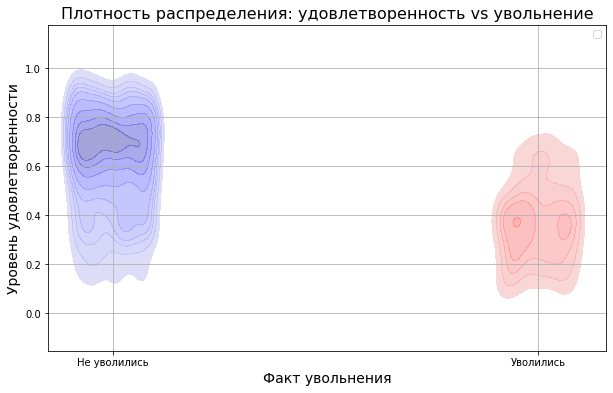

In [100]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_quit,
    x='binary_var_jittered',
    y='job_satisfaction_rate',
    hue='quit',
    palette={'no': "blue", 'yes': "red"},
    alpha=0.5,
    fill=True,
    levels=10,
    thresh=0.1
)

plt.xticks([0, 1], ['Не уволились', 'Уволились'])
plt.title('Плотность распределения: удовлетворенность vs увольнение', size=16)
plt.xlabel('Факт увольнения', size=14)
plt.ylabel('Уровень удовлетворенности', size=14)
plt.grid(True)
plt.legend(title='')
plt.show()

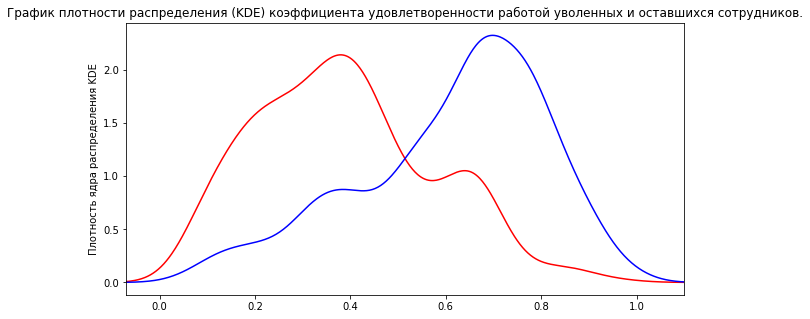

* налицо разная плотность распределения уровня удовлетворенности уволившихся и тех кто не уволился, прямо-пропорциональная зависимость

* Проведем коррелляционный анализ новых данных

In [79]:
train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


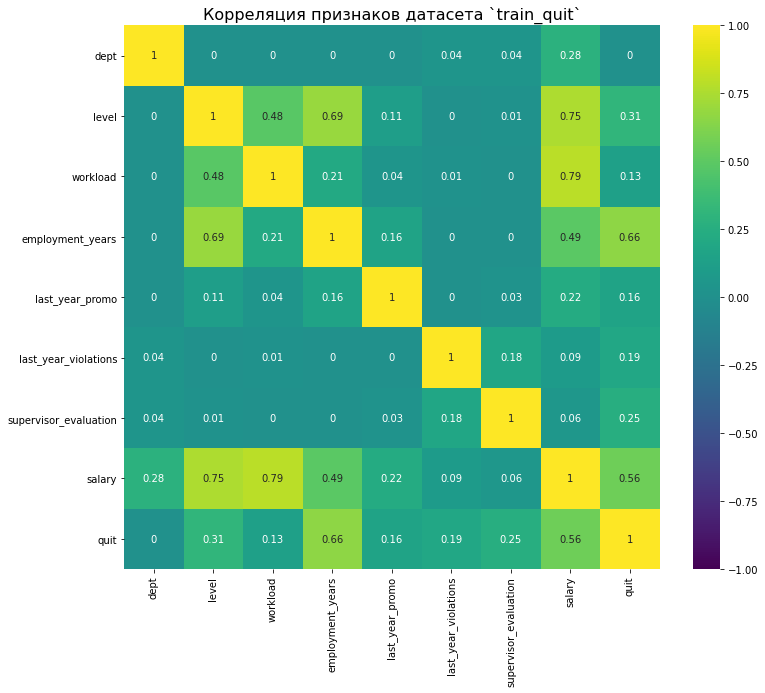

In [80]:
phi_corr = train_quit.drop(['id'], 
     axis=1).phik_matrix(interval_cols=[
    'employment_years', 'supervisor_evaluation', 'salary',
    'job_satisfaction_rate']).round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(phi_corr, annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title('Корреляция признаков датасета `train_quit`', size=16)
plt.show()

В данной матрице у нас ничего нового, все также как и в предыдущих, такие же закономерности.

### Промежуточный вывод

* По колличеству уволившихся лидируют отделы:
    * продаж и технологический
    * остальные находятся примернно на одном уровне
    
* при рассмотрении доли уволившихся по отделам в разрезе уровня нагруженности:
    * на первом месте 30% уволившихся в технологическом отделе, при этом нагрузка находится практически на минимальном уровне
    * среди остальных можно выделить отдел марктинга и продаж по 28%, имеют нагруженность выше среднего.
    * самая маленькая нагруженность и доля уволившихся в отделе hr
    
* при рассмотрении доли уволившихся по отделам в разрезе уровня заработка:
    * на первом месте все аткже 30% уволившихся в технологическом отделе, при этом заработок там на максимальном уровне по отношению к другим
    * среди остальных можно выделить отдел марктинга, закупок и продаж по 28%, имеют уровень заработка (маркетинг - средний, закупок и продаж самые низкие).
    * самая маленькая доля уволившихся в отделе hr, с уровнем заработка чуть ниже среднего
* Сравнение средних значений зарплат, и их разброса по сегментам уволившихся и тех кто остался, показывает, что увольняются чаще те, кто получает зарплаты ниже среднего.<br>
Рискованные сегменты:<br>
- junior, получающий менее 22000.
- middle, получающий менее 36000. 
- sinior, получающий менее 50000.<br>
* большинство мидл и синиор сотрудников (оно и понятно что не джуниоров), которые остаются в компании работают свыше 4 лет.
* Большинство уволившихся сотрудников в разных сегментах работали в компании меньше 5лет. 
* Рискованные сегменты:
    - junior, работающий менее 2 лет.
    - middle, работающий менее 5 лет. 
    - sinior, работающий менее 6 лет.
    
* налицо разная плотность распределения уровня удовлетворенности уволившихся и тех кто не уволился, прямо-пропорциональная зависимость

## Добавление нового входного признака

### Допустим, 'job_satisfaction_rate' и 'quit' действительно связаны и вы получили необходимое значение метрики в первой задаче. Тогда добавьте 'job_satisfaction_rate', предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.

In [81]:
train_quit['job_satisfaction_rate'] = randomized_search.predict(train_quit)
test_features['job_satisfaction_rate'] = randomized_search.predict(test_features)
train_quit.head()

/opt/conda/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,0.653333
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.846364
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.340000
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.380000
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.690000


In [82]:
test_features.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.875000
1,686555,hr,junior,medium,1,no,no,4,30000,0.667105
2,467458,sales,middle,low,5,no,no,4,19200,0.654000
3,418655,sales,middle,low,6,no,no,4,19200,0.655000
4,789145,hr,middle,medium,5,no,no,5,40800,0.845000


* Добавили новый входной признак, использоваав предыдущую модель с прогнозированием удовлетворенности сотрудника в данные ко второй задаче.

## Подготовка данных

In [83]:
test_df_2 = pd.merge(test_features,test_target_quit, on='id', how='inner')

In [84]:
test_df_2.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.875000,no
1,686555,hr,junior,medium,1,no,no,4,30000,0.667105,no
2,467458,sales,middle,low,5,no,no,4,19200,0.654000,no
3,418655,sales,middle,low,6,no,no,4,19200,0.655000,no
4,789145,hr,middle,medium,5,no,no,5,40800,0.845000,no


In [85]:
train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,0.653333
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.846364
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.340000
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.380000
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.690000


In [86]:
RANDOM_STATE = 42

X_train = train_quit.drop(['quit', 'id'], axis=1)
y_train = train_quit['quit']
X_test = test_df_2.drop(['id', 'quit'], axis=1)
y_test = test_df_2['quit']

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test =  le.transform(y_test)

ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level', 'workload']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']

ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='error', sparse=False))
    ]
    )

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'sinior'],
                    ['low', 'medium', 'high']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', RobustScaler(), num_columns)
    ], 
    remainder='passthrough'
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('selector', SelectKBest(score_func=f_regression)),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

### Промежуточный вывод

Аналогично как и в первой задаче, при подготовке данных был использован pipeline. Подготовку признаков выполнили в пайплайне, дополнив пайплайн шагом предобработки. При кодировании использовали как два кодировщика, а также подготовили селектор для подбора лучшего сочетания параметров.

## Обучение модели

In [87]:
param_grid = [
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 7),
        'models__max_features': range(2, 7),
        'selector__k': [5, 8, 10, 'all'],
        'selector__score_func': [f_classif],
        'preprocessor__num': [MinMaxScaler(), StandardScaler(), 'passthrough']  
    },
    
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 30),
        'selector__k': [5, 8, 10, 'all'],
        'selector__score_func': [f_classif, mutual_info_classif],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'selector__k': [5, 8, 10, 'all'],
        'selector__score_func': [f_classif],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    {
        'models': [SVC(random_state=RANDOM_STATE)],
        'selector__k': [5, 8, 10, 'all'],
        'selector__score_func': [f_classif],
        'preprocessor__num': [StandardScaler(), 'passthrough']  
    },
]

randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_iter=20
)
randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_)

y_test_pred = randomized_search.predict_proba(X_test)[:, 1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                              

* Сохраним данные по всем моделям в датафрейм. Отсортируем модели по лучшему результату rank_test_score и выведем оценки топ 10 моделей

In [88]:
results_2 = pd.DataFrame(randomized_search.cv_results_)
best_results_2 = results.sort_values(by='mean_test_score', ascending=False)
best_results_2.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_selector__score_func,param_selector__k,param_preprocessor__num,param_models__max_features,param_models__max_depth,param_models,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,0.104104,0.007688,0.077633,0.033336,<function f_regression at 0x7f8993b41430>,all,passthrough,0.7,14,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-15.605657,-15.318792,-16.527001,-16.619386,-15.886283,-15.991424,0.508623,1
18,0.084156,0.066753,0.117097,0.041208,<function f_regression at 0x7f8993b41430>,all,StandardScaler(),0.5,15,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-16.759490,-16.556851,-17.369350,-16.619408,-17.171867,-16.895393,0.319475,2
7,0.074727,0.032320,0.105831,0.034435,<function f_regression at 0x7f8993b41430>,all,StandardScaler(),auto,7,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-18.288828,-16.870524,-19.076341,-18.826786,-18.662191,-18.344934,0.780362,3
11,0.060561,0.042091,0.120049,0.045390,<function f_regression at 0x7f8993b41430>,all,StandardScaler(),0.7,6,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-19.866974,-18.958545,-20.147330,-20.484096,-19.870789,-19.865547,0.506890,4
10,0.078742,0.043680,0.119308,0.047697,<function f_regression at 0x7f8993b41430>,5,RobustScaler(),0.5,6,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-21.424877,-20.234711,-22.096556,-22.011482,-20.299797,-21.213485,0.806737,5
6,0.080077,0.043212,0.119856,0.043795,<function f_regression at 0x7f8993b41430>,5,RobustScaler(),0.7,11,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-20.999163,-20.832097,-21.698827,-22.508428,-20.737017,-21.355106,0.667917,6
16,0.098179,0.035372,0.083037,0.004680,<function f_regression at 0x7f8993b41430>,all,RobustScaler(),auto,4,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-21.641458,-20.724117,-22.637705,-21.792710,-20.808390,-21.520876,0.704017,7
13,0.062674,0.045781,0.118414,0.045531,<function f_regression at 0x7f8993b41430>,5,RobustScaler(),auto,4,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-21.765664,-20.747210,-22.676755,-21.831474,-21.334370,-21.671095,0.634502,8
3,0.076077,0.042627,0.102224,0.038119,<function f_regression at 0x7f8993b41430>,3,StandardScaler(),0.7,16,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-22.676659,-20.775262,-22.436999,-21.895903,-21.526992,-21.862363,0.676561,9
4,0.096077,0.036095,0.102791,0.037109,<function f_regression at 0x7f8993b41430>,3,RobustScaler(),0.7,15,"DecisionTreeRegressor(max_depth=14, max_featur...",{'selector__score_func': <function f_regressio...,-22.676659,-20.775262,-22.436999,-21.895903,-21.526992,-21.862363,0.676561,9


### Оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP

  0%|          | 0/2000 [00:00<?, ?it/s]

Best parameters: {'selector__score_func': <function f_classif at 0x7f8993b411f0>, 'selector__k': 8, 'preprocessor__num': StandardScaler(), 'models__n_neighbors': 17, 'models': KNeighborsClassifier(n_neighbors=17)}


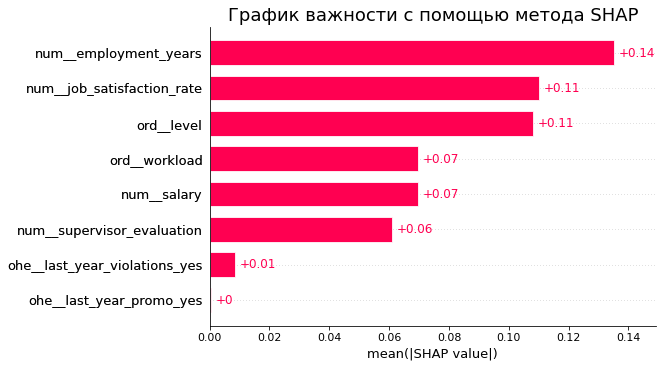

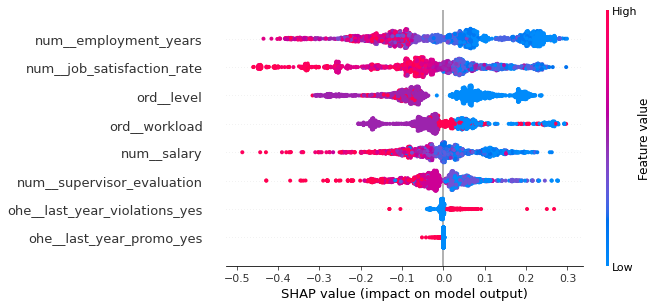

In [89]:
best_pipeline = randomized_search.best_estimator_
selector = best_pipeline.named_steps['selector']
knn_model = best_pipeline.named_steps['models']
    
preprocessor = best_pipeline.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()
X_train_transformed = pd.DataFrame(
    preprocessor.transform(X_train), 
    columns=feature_names
)
X_test_transformed = pd.DataFrame(
    preprocessor.transform(X_test), 
    columns=feature_names
)

X_train_selected = selector.fit_transform(X_train_transformed, y_train)
X_test_selected = selector.transform(X_test_transformed)
selected_feature_names = feature_names[selector.get_support()]

selected_mask = selector.get_support()
selected_feature_names = feature_names[selected_mask]

selector.feature_names_in_ = preprocessor.get_feature_names_out()
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names)

background = shap.sample(X_train_selected, 100)

explainer = shap.KernelExplainer(
        knn_model.predict,
        background,
        feature_names=feature_names,
        n_jobs=-1
    )

shap_values = explainer(X_test_selected_df)

plt.title('График важности с помощью метода SHAP', size=18)
print(f'Best parameters: {randomized_search.best_params_}')
#shap.plots.bar(shap_values[...,1])
shap.plots.bar(shap_values, max_display=17)
shap.plots.beeswarm(shap_values, max_display=17)
plt.show()

### Метрика оценки качества в этой задаче — ROC-AUC. Критерий успеха: ROC-AUC ≥0.91 на тестовой выборке. Напомним: отбор признаков часто помогает улучшить метрику.

Ваша вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании. 

In [90]:
predict_2 = randomized_search.predict(X_test)
recall = recall_score(y_test, predict_2)
print(recall)

0.7943262411347518


/opt/conda/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


### Построим матрицу ошибок и сохраним её в переменную

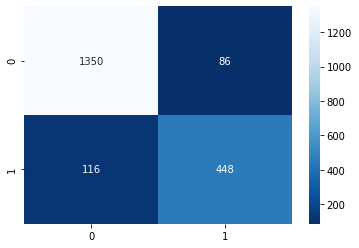

In [91]:
cm = confusion_matrix(y_test, predict_2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r');

В основном все кто уволился были предсказаны верно, и хотя roc-auc показала себя не плохо, но ошибок модели всё ещё достаточно много

### Промежуточный вывод

1. Использовав один общий пайплайн для всех моделей и инструмент подбора гиперпараметров, мы нашли лучшую модель и гиперпараметры.
В нашем случае модель - **`'KNeighborsClassifier'`** с гиперпараметром: (n_neighbors=17):
* Большое число соседей (n_neighbors=17):
    * Снижает чувствительность к выбросам
    * Дает более устойчивые прогнозы за счет "голосования большинства".
2. SelectKBest(k=8) устранил потенциально избыточные или шумные признаки, уменьшил риск переобучения
3. Метрика лучшей модели на тренировочной выборке: 0.9340657711531012<br>
    Метрика ROC-AUC на тестовой выборке: 0.9239706187399988
   
4. KNN хорошо ловит сложные нелинейные границы, которые линейные модели (логистическая регрессия, лес деревьев)  могли не уловить

* На основании predict_proba поделим сотрудников та тех,  чей риск увольнения низкий(<0.4), средний(от порога высокого до <=0.7), и высокий (свыше 0.7) 

In [92]:
test_features['prob_quit'] = randomized_search.best_estimator_.predict_proba(X_test)[:,1]
test_features.head()

/opt/conda/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,prob_quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.875000,0.117647
1,686555,hr,junior,medium,1,no,no,4,30000,0.667105,0.176471
2,467458,sales,middle,low,5,no,no,4,19200,0.654000,0.117647
3,418655,sales,middle,low,6,no,no,4,19200,0.655000,0.117647
4,789145,hr,middle,medium,5,no,no,5,40800,0.845000,0.000000


* Создадим сегменты по результатам моделирования

In [93]:
def categorize(df):
    prog_rate = df['prob_quit']
    if prog_rate <= 0.4:
        return 'low'
    elif prog_rate > 0.4 and prog_rate <= 0.7:
        return 'medium'
    else:
        return 'hight'

test_features['risk_quit'] = test_features.apply(categorize, axis=1)
test_features.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,prob_quit,risk_quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.875000,0.117647,low
1,686555,hr,junior,medium,1,no,no,4,30000,0.667105,0.176471,low
2,467458,sales,middle,low,5,no,no,4,19200,0.654000,0.117647,low
3,418655,sales,middle,low,6,no,no,4,19200,0.655000,0.117647,low
4,789145,hr,middle,medium,5,no,no,5,40800,0.845000,0.000000,low


In [94]:
test_features[test_features['risk_quit'] == 'hight'].describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate,prob_quit
count,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000
mean,557211.127660,1.629787,2.865957,22097.872340,0.368360,0.884481
std,245401.754592,0.904364,0.888874,7514.270414,0.173795,0.094966
min,103221.000000,1.000000,1.000000,12000.000000,0.060000,0.705882
25%,358474.500000,1.000000,2.000000,15600.000000,0.211250,0.823529
50%,549640.500000,1.000000,3.000000,21600.000000,0.341875,0.882353
75%,762504.000000,2.000000,3.000000,26400.000000,0.514167,0.985294
max,999029.000000,5.000000,5.000000,48000.000000,0.740000,1.000000


## Вывод по задаче 2

Задача 2: Найти модель, которая наилучшим образом предсказывает уволится сотрудник или нет.

* На этапе предобработки данных был схож с 1 задачей абсолютно.
* На этапе исследования данных:

    * По колличеству уволившихся лидируют отделы:
        * продаж и технологический
        * остальные находятся примернно на одном уровне
    
    * при рассмотрении доли уволившихся по отделам в разрезе уровня нагруженности:
        * на первом месте 30% уволившихся в технологическом отделе, при этом нагрузка находится практически на минимальном уровне
        * среди остальных можно выделить отдел марктинга и продаж по 28%, имеют нагруженность выше среднего.
        * самая маленькая нагруженность и доля уволившихся в отделе hr
    
    * при рассмотрении доли уволившихся по отделам в разрезе уровня заработка:
        * на первом месте все аткже 30% уволившихся в технологическом отделе, при этом заработок там на максимальном уровне по отношению к другим
        * среди остальных можно выделить отдел марктинга, закупок и продаж по 28%, имеют уровень заработка (маркетинг - средний, закупок и продаж самые низкие).
        * самая маленькая доля уволившихся в отделе hr, с уровнем заработка чуть ниже среднего
    
    * налицо разная плотность распределения уровня удовлетворенности уволившихся и тех кто не уволился, прямо-пропорциональная зависимость

* Подхотовка данных и обучение модели были произведены по аналогии с задачей 1, единственное, мы кодировали целевой признак тоже. И учитывали особенности логистической регрессии.

* Итоги по проделанной работе.

* Мы для оценки модели использовали ROC-AUC метрику, с порогом не ниже 0.91, также проверили через recall и матрицу ошибок как работает модель.
* Использовав один общий пайплайн для всех моделей и инструмент подбора гиперпараметров, мы нашли лучшую модель и гиперпараметры.
* В нашем случае модель - **`'KNeighborsClassifier'`** с гиперпараметром: (n_neighbors=17):
    * Большое число соседей (n_neighbors=17):
        * Снижает чувствительность к выбросам
        * Дает более устойчивые прогнозы за счет "голосования большинства".
        * SelectKBest(k=8) устранил потенциально избыточные или шумные признаки, уменьшил риск переобучения
        * Метрика лучшей модели на тренировочной выборке: 0.9340657711531012<br>
        * Метрика ROC-AUC на тестовой выборке: 0.9239706187399988
   
* KNN хорошо ловит сложные нелинейные границы, которые линейные модели (логистическая регрессия, лес деревьев)  могли не уловить

## Общий вывод

* Для любой организации важно не просто привлечь сотрудника, но и удержать специалиста, если он важный и показывает наилучший результат, а так же стимулировать вовлечение работников в процессы компании и увеличивать их мотивацию. В ходе проделанной работы были найдены две модели:

* модель, которая наилучшим образом предсказывают степень удовлетворённости рабочими процессами у сотрудников компании в разных сегментах. DecisionTreeRegressor, с парамметрами:max_depth=14, max_features=0,7, random_state=42, и метрикой на тестовых данных 14.8.
* модель, которая прогнозирует риски увольнения сотрудников. D**`'KNeighborsClassifier'`** с гиперпараметром: (n_neighbors=17). С метрикой на тестовых данных - 0.923**
* Мы смогли описать факторы, влияющие на оценку, которую работкник ставит компании:

* Самым важным фактором модель сочла длительность работы в компании. В целом исследовательский анализ также подствердил связь времени работы сотрудников в компании и степерью их удовлетворенности работой. Как же это влиет, согласно анализу shap:
   - Чем больше лет человек проработал, тем выше будет его оценка раб. процессу. Благодая исследовани признаков мы увидели, что оценку удовлетворенности выше среднего чаще ставят группы работников уровня junior, проработашие более 1 года, middle, проработавшие свыше 5 лет, и sinior, проработавшие более 7 лет. Эти категории наименее рискованные из всех. Остальные в зоне риска.
     
* Вторым по важности признаков модель выывела - оценку работы сотрудника руководителем. Согласно анализу shap, чем выше оценивает руководитель работу сотрудника, тем выше сотрудник оценивает свои условия труда в компании, и такая же обратная связь. 
      
* На третем месте сразу два признака. Зарплата и было ли нарушение трудового договора за последний год. 
   * Зарплата действительно влияет на степень удовлетворенности сотрудниками работой. Согласно исследованию, были выявлены очень чувствительные сегменты работников, к размеру зарплаты.Самые низкие средние зарплаты в отделе sales, при этом ниже всего оценивают удовлетворенность sinior в данной группе - это высокий риск потери первоклассных специалистов, способных увести базу покупателей за собой, уйдя из компании, а также переманить специалистов своего отдела.
   * Согласно исследованию и интерпретации значения признаков методом shap, наличие нарушений трудового договора - это сигнал о том, что сотрудник не доволен тем как организован его рабочий процесс, тут нужно разбираться детальнее, о каких нарушениях речь, возможно снизить риск снижения удовлетворённости данных сотрудников поможет снизить пересмотр условий труда, а не наказание за нарушение договора.


* Cотрудники, риск увольнения которых достаточно высок:

    * с наивысшей вероятностью сотрудники отделов sales и technology.
    * сотрудники с оценкой удовлетворенности работой ниже 0.5% следующих сегментов:
    * junior, работающий менее 2 лет и с зарплатой ниже 22 000 рублей.
    * middle, работающий менее 5 лет и с зарплатой ниже 35 000 рублей.
    * sinior, работающий менее 6 лет и с зарплатой ниже 50 000 рублей.

А также выявили количество сотрудников с высоким риском увольнения. С высоким риском их оказалось 21%, а со средним - 9% на тестовой выборке.

Рекомендации для бизнеса:

Стимулировать новых сотрудников остатья в компании путём их наибольшего вовлечения в процессы, увеличением зарплаты и мотивацией перехода по уровню квалификации, то есть признанием их навыков.
Внимательно отнестись к отделу продаж, пересмотреть финансовую мотивацию, по всем показателям это самый сложный отдел, с точки зрения того, что там самые низкие зарплаты у сотрудников, и это прямо влияет на их жизненный цикл в компании и мотивацию их нахождения в организации.
Следить за тем,чтобы сотрудники не были перегружены, либо за тем, чтобы им не приходилось нарушать трудовой договор, выявить причины нарушения и выстроить план по снижению риска нарушения договора(зачастую прогулы, опоздание, вызваны перегруженностью и выгоранием сотрудников).
Достаточно много сотрудников среди средне и высококвалифицированных годами не получают повышений и находятся на зарплатном уровне ниже среднего даже в своих отделах. Этот разрыв нужно либо какии-то объективным образом объяснять. Либо награждать сотрудников заслуженными повышениями в должности и зарплатами. ВОзможно стоит поработать над системой премирования, KPI, что позволило бы организации выстроить систему доплат сотрудникам за их рабочие достижения в компании.